# 🌫️ Beijing Air Pollution Analysis & Prediction Project

Welcome to the final project on air pollution analysis using real-world data from Beijing.

## 🔗 Useful Links

- 📁 **GitHub Repository**: [View on GitHub](https://github.com/iamapilotstar/Air-Pollution-Classification)
- 🌐 **Live Streamlit App**: [Try the Web App](https://airpollutionclassification.streamlit.app/)

This notebook includes:
- Geographically diverse site selection
- In-depth EDA (Exploratory Data Analysis)
- Feature engineering and transformation
- Handling missing data and class imbalance
- Model training, tuning, and evaluation
- SHAP explainability and interpretation

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.1 MB/s eta 0:00:00


In [ ]:
!pip install folium

In [ ]:
!pip install plotly


In this section, I imported essential Python libraries for data analysis, visualization, and machine learning.

- **pandas** and **numpy**: For data manipulation.
- **matplotlib** and **seaborn**: For data visualization.
- **scikit-learn** models and tools: For building classification models.
- **catboost**, **lightGBM**, and **imbalanced-learn (SMOTE)**: For boosting and handling imbalanced data.
- I also disabled warnings to keep the notebook clean and readable.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, FunctionTransformer
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

import pickle
import shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

To conduct a geographically diverse and insightful analysis of air quality, I selected five representative monitoring sites across different regions of Beijing. These stations were chosen to cover a range of environmental and socio-economic conditions, which helps in understanding how pollution levels vary across urban, rural, and industrial landscapes.

- **Aotizhongxin (Industrial)**: This site is located near Beijing’s Olympic Sports Center, a zone that also includes dense traffic and industrial activity. It provides insights into pollution in high-activity urban-industrial zones.

- **Dongsi (Urban)**: Located in the city center, Dongsi is a densely populated urban area with heavy traffic. It helps us analyze typical urban pollution levels where population exposure is highest.

- **Changping (Suburban)**: Positioned at the edge of urban expansion, Changping is undergoing rapid residential and commercial development. By including Changping, I can track pollution gradient changes in middle ground between urban and rural, useful for detecting early signs of pollution creep from the city.

- **Huairou (Rural)**: This site is in a mountainous area with low human activity and fewer pollution sources. It serves as a baseline for comparing air quality in less polluted, greener regions.

- **Shunyi (Semi-Rural / Airport Zone)**: Shunyi is located near Beijing Capital Airport and is less densely populated, yet influenced by aircraft emissions and suburban transport. It provides a unique perspective on non-industrial, transport-related pollution in outer zones.

## 📌 Why These Sites? (Geographical Disadvantage)

This **diverse selection** allows meaningful analysis of how **air pollution varies by land use**, traffic intensity, and local development. Research shows that **urban-industrial regions** experience consistently higher pollutant concentrations due to mixed sources (Zhang et al., 2015). Meanwhile, **rural and suburban areas** act as comparators to highlight disparities caused by infrastructure, wind flow, and emissions control.

> **Reference**:  
Zhang, Y.-L. and Cao, F. (2015) ‘Fine particulate matter (PM 2.5 ) in China at a city level’, Scientific Reports, 5(1), pp. 1–12. Available at: https://doi.org/10.1038/srep14884.


In [ ]:
df_aoti = pd.read_csv('/content/drive/MyDrive/Assignment/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
df_changping = pd.read_csv('/content/drive/MyDrive/Assignment/PRSA_Data_Changping_20130301-20170228.csv')
df_dongsi = pd.read_csv('/content/drive/MyDrive/Assignment/PRSA_Data_Dongsi_20130301-20170228.csv')
df_huairou = pd.read_csv('/content/drive/MyDrive/Assignment/PRSA_Data_Huairou_20130301-20170228.csv')
df_shunyi = pd.read_csv('/content/drive/MyDrive/Assignment/PRSA_Data_Shunyi_20130301-20170228.csv')

After loading the five selected air quality datasets, I added two new columns to each of them:

1. `station` – to identify which monitoring site the data is from.
2. `area_type` – to categorize each station based on its location (e.g., Urban, Rural, Industrial, etc.).

Once the columns were added, I merged all the individual datasets into one using `pd.concat()`. This allowed me to work with one big DataFrame instead of multiple files. I also dropped the `No` column since it was just an index and didn’t add any value to the analysis.

By combining everything into a single DataFrame called `df`, I now have a clean, organized dataset that covers a variety of regions in Beijing. This makes it easier to compare how air pollution and weather conditions change based on where the station is located. It also sets things up nicely for grouped analysis and modeling later on.



In [ ]:
df_aoti['station'] = 'Aotizhongxin'
df_changping['station'] = 'Changping'
df_dongsi['station'] = 'Dongsi'
df_huairou['station'] = 'Huairou'
df_shunyi['station'] = 'Shunyi'

To perform meaningful geographical analysis, I added a new column called `area_type` to each station's dataset.

This column labels each station according to its location type:
- Urban
- Rural
- Suburban
- Industrial
- Semi-Rural

This will allow me to group and compare pollution levels and weather patterns based on location type, making the analysis more insightful and structured. It also prepares the data for grouped visualizations and modeling later on.


In [ ]:
df_aoti['area_type'] = 'Industrial'
df_changping['area_type'] = 'Suburban'
df_dongsi['area_type'] = 'Urban'
df_huairou['area_type'] = 'Rural'
df_shunyi['area_type'] = 'Semi-Rural'

In [ ]:
df = pd.concat([df_aoti, df_changping, df_dongsi, df_huairou, df_shunyi], ignore_index=True)

In [ ]:
df.head(10)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,area_type
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,Industrial
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,Industrial
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,Industrial
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,Industrial
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,Industrial
5,6,2013,3,1,5,5.0,5.0,18.0,18.0,400.0,66.0,-2.2,1025.6,-19.6,0.0,N,3.7,Aotizhongxin,Industrial
6,7,2013,3,1,6,3.0,3.0,18.0,32.0,500.0,50.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Aotizhongxin,Industrial
7,8,2013,3,1,7,3.0,6.0,19.0,41.0,500.0,43.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Aotizhongxin,Industrial
8,9,2013,3,1,8,3.0,6.0,16.0,43.0,500.0,45.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Aotizhongxin,Industrial
9,10,2013,3,1,9,3.0,8.0,12.0,28.0,400.0,59.0,1.2,1028.5,-19.3,0.0,N,2.6,Aotizhongxin,Industrial


In [ ]:
df.shape

(175320, 19)

In [ ]:
coords = {
    'Aotizhongxin': [39.982, 116.397],
    'Dongsi': [39.929, 116.417],
    'Changping': [40.218, 116.231],
    'Huairou': [40.317, 116.637],
    'Shunyi': [40.125, 116.655],
}

df['lat'] = df['station'].map(lambda x: coords[x][0])
df['lon'] = df['station'].map(lambda x: coords[x][1])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175320 entries, 0 to 175319
Data columns (total 21 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   No         175320 non-null  int64  
 1   year       175320 non-null  int64  
 2   month      175320 non-null  int64  
 3   day        175320 non-null  int64  
 4   hour       175320 non-null  int64  
 5   PM2.5      171005 non-null  float64
 6   PM10       172142 non-null  float64
 7   SO2        170818 non-null  float64
 8   NO2        169025 non-null  float64
 9   CO         165226 non-null  float64
 10  O3         169693 non-null  float64
 11  TEMP       175125 non-null  float64
 12  PRES       175126 non-null  float64
 13  DEWP       175120 non-null  float64
 14  RAIN       175123 non-null  float64
 15  wd         174236 non-null  object 
 16  WSPM       175156 non-null  float64
 17  station    175320 non-null  object 
 18  area_type  175320 non-null  object 
 19  lat        175320 non-n

In [ ]:
df.drop(['No'],axis=1,inplace=True, errors='ignore')


In [ ]:
df[['station', 'area_type']].drop_duplicates()

,station,area_type
0,Aotizhongxin,Industrial
35064,Changping,Suburban
70128,Dongsi,Urban
105192,Huairou,Rural
140256,Shunyi,Semi-Rural


In [ ]:
df.head(10)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,area_type,lat,lon
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,Industrial,39.982,116.397
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,Industrial,39.982,116.397
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,Industrial,39.982,116.397
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,Industrial,39.982,116.397
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,Industrial,39.982,116.397
5,2013,3,1,5,5.0,5.0,18.0,18.0,400.0,66.0,-2.2,1025.6,-19.6,0.0,N,3.7,Aotizhongxin,Industrial,39.982,116.397
6,2013,3,1,6,3.0,3.0,18.0,32.0,500.0,50.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Aotizhongxin,Industrial,39.982,116.397
7,2013,3,1,7,3.0,6.0,19.0,41.0,500.0,43.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Aotizhongxin,Industrial,39.982,116.397
8,2013,3,1,8,3.0,6.0,16.0,43.0,500.0,45.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Aotizhongxin,Industrial,39.982,116.397
9,2013,3,1,9,3.0,8.0,12.0,28.0,400.0,59.0,1.2,1028.5,-19.3,0.0,N,2.6,Aotizhongxin,Industrial,39.982,116.397


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175320 entries, 0 to 175319
Data columns (total 20 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   year       175320 non-null  int64  
 1   month      175320 non-null  int64  
 2   day        175320 non-null  int64  
 3   hour       175320 non-null  int64  
 4   PM2.5      171005 non-null  float64
 5   PM10       172142 non-null  float64
 6   SO2        170818 non-null  float64
 7   NO2        169025 non-null  float64
 8   CO         165226 non-null  float64
 9   O3         169693 non-null  float64
 10  TEMP       175125 non-null  float64
 11  PRES       175126 non-null  float64
 12  DEWP       175120 non-null  float64
 13  RAIN       175123 non-null  float64
 14  wd         174236 non-null  object 
 15  WSPM       175156 non-null  float64
 16  station    175320 non-null  object 
 17  area_type  175320 non-null  object 
 18  lat        175320 non-null  float64
 19  lon        175320 non-n

#EDA

In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (175320, 20)

Data Types:
 year           int64
month          int64
day            int64
hour           int64
PM2.5        float64
PM10         float64
SO2          float64
NO2          float64
CO           float64
O3           float64
TEMP         float64
PRES         float64
DEWP         float64
RAIN         float64
wd            object
WSPM         float64
station       object
area_type     object
lat          float64
lon          float64
dtype: object

Missing Values:
 year             0
month            0
day              0
hour             0
PM2.5         4315
PM10          3178
SO2           4502
NO2           6295
CO           10094
O3            5627
TEMP           195
PRES           194
DEWP           200
RAIN           197
wd            1084
WSPM           164
station          0
area_type        0
lat              0
lon              0
dtype: int64


In [ ]:
df['wd'].unique()

array(['NNW', 'N', 'NW', 'NNE', 'ENE', 'E', 'NE', 'W', 'SSW', 'WSW', 'SE',
       'WNW', 'SSE', 'ESE', 'S', 'SW', nan], dtype=object)

In [ ]:
df['wd'].value_counts()

,count
wd,
NE,16004
NW,15553
N,12952
ENE,12558
NNE,12519
WNW,12252
E,11911
NNW,11377
ESE,10608


In [ ]:
df['station'].unique()

array(['Aotizhongxin', 'Changping', 'Dongsi', 'Huairou', 'Shunyi'],
      dtype=object)

In [ ]:
df['station'].value_counts()

,count
station,
Aotizhongxin,35064
Changping,35064
Dongsi,35064
Huairou,35064
Shunyi,35064


In [ ]:
df['area_type'].value_counts()

,count
area_type,
Industrial,35064
Suburban,35064
Urban,35064
Rural,35064
Semi-Rural,35064


In [ ]:
df['PM2.5'] = df.groupby('area_type')['PM2.5'].transform(lambda x: x.fillna(x.median()))

# 🗺️ Interactive Map of Air Quality Stations Using Folium

To provide a **visual understanding** of how air pollution varies geographically, I used `Folium` to create an interactive map of the five selected stations.

To maintain class balance and model interpretability, PM2.5 values were grouped into three categories — Low, Medium, and High — based on official Chinese AQI thresholds (Wang et al., 2014b) as documented in the Ministry of Environmental Protection of China (2012) standards. A 3-class classification was selected to reduce overfitting risk and enhance usability in a real-time prediction interface, an approach supported by (Feng et al., 2015) who demonstrated that simplified categorical predictions improve operational utility in environmental monitoring systems.

Each station is shown as a circle marker, color-coded by PM2.5 pollution level:

- 🟢 **Green**: PM2.5 <= 35 (Low)
- 🟠 **Orange**: PM2.5 <= 75 (Medium)
- 🔴 **Red**: PM2.5 > 75 μg/m³ (High)

This map offers an intuitive, spatial overview of air quality **disparities** between industrial, urban, suburban, and rural regions.

> **Reference**:  
Wang, Y. et al. (2014b) ‘Spatial and temporal variations of six criteria air pollutants in 31 provincial capital cities in China during 2013–2014’, Environment International, 73, pp. 413–422. Available at: https://doi.org/10.1016/j.envint.2014.08.016.

Feng, X. et al. (2015) ‘Artificial neural networks forecasting of PM2.5 pollution using air mass trajectory based geographic model and wavelet transformation’, Atmospheric Environment, 107, pp. 118–128. Available at: https://doi.org/10.1016/j.atmosenv.2015.02.030.

In [ ]:
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].median())

def categorize_pm25(value):
    if pd.isna(value):
        return 'Unknown'
    elif value <= 35:
        return 'Low'
    elif value <= 75:
        return 'Medium'
    else:
        return 'High'

df['PM2.5_category'] = df['PM2.5'].apply(categorize_pm25)

In [ ]:
df.head(3)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,PRES,DEWP,RAIN,wd,WSPM,station,area_type,lat,lon,PM2.5_category
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,...,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,Industrial,39.982,116.397,Low
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,...,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,Industrial,39.982,116.397,Low
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,...,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,Industrial,39.982,116.397,Low


In [ ]:
df['PM2.5_category'].value_counts()

,count
PM2.5_category,
Low,66020
High,65158
Medium,44142


To improve performance and clarity, I used animated air quality map with daily averages. To make the animation run more smoothly I ommited the hourly averages and took daily.

Each bubble represents a station, and its color and size reflect the average PM2.5 level for that day. This visualization clearly shows pollution trends across different locations over time.


In [ ]:
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df_daily = df.groupby(['station', 'date'])[['PM2.5', 'lat', 'lon']].mean().reset_index()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175320 entries, 0 to 175319
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   year            175320 non-null  int64         
 1   month           175320 non-null  int64         
 2   day             175320 non-null  int64         
 3   hour            175320 non-null  int64         
 4   PM2.5           175320 non-null  float64       
 5   PM10            172142 non-null  float64       
 6   SO2             170818 non-null  float64       
 7   NO2             169025 non-null  float64       
 8   CO              165226 non-null  float64       
 9   O3              169693 non-null  float64       
 10  TEMP            175125 non-null  float64       
 11  PRES            175126 non-null  float64       
 12  DEWP            175120 non-null  float64       
 13  RAIN            175123 non-null  float64       
 14  wd              174236 non-null  obj

In [ ]:
fig = px.scatter_mapbox(
    df_daily,
    lat="lat",
    lon="lon",
    color="PM2.5",
    size="PM2.5",
    size_max=30,
    animation_frame=df_daily["date"].dt.strftime('%Y-%m-%d'),
    animation_group="station",
    hover_name="station",
    color_continuous_scale="Turbo",
    mapbox_style="carto-positron",
    zoom=8,
    center={"lat": 39.9, "lon": 116.4},
    title="Daily PM2.5 Levels Across Beijing Monitoring Stations"
)

fig.show()


To further explore the trend of air pollution over time, I created a line plot showing daily average PM2.5 levels for each monitoring station.

This plot helps identify:
- Which areas consistently experience higher pollution
- Seasonal trends (e.g., winter spikes)
- How pollution changes together or differently across regions

Combined with the animated map, this line chart provides both spatial and temporal perspectives of air quality in Beijing.


In [ ]:
fig = px.line(
    df_daily,
    x="date",
    y="PM2.5",
    color="station",
    title="Daily Average PM2.5 Levels by Station",
    labels={"PM2.5": "PM2.5 Concentration", "date": "Date"},
    line_shape="spline"
)

fig.show()

In [ ]:
df.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,DEWP,RAIN,wd,WSPM,station,area_type,lat,lon,PM2.5_category,date
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,...,-18.8,0.0,NNW,4.4,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,...,-18.2,0.0,N,4.7,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,...,-18.2,0.0,NNW,5.6,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,...,-19.4,0.0,NW,3.1,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,...,-19.5,0.0,N,2.0,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01


To understand how often different pollution levels occur in the dataset, I used `value_counts()` on the `PM2.5_category` column. This tells me how many observations fall into each pollution category (e.g., Low, Medium, High).

This step gives an initial overview of air quality severity distribution across the dataset and sets the stage for further visualization.


I checked for missing values across all columns using `isnull().sum()`. This is a basic but crucial step in data cleaning, as missing values can affect model performance and analysis.

Based on the result, I decided which columns needed to be imputed or ignored for analysis.


In [ ]:
df.isnull().sum()

,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,3178
SO2,4502
NO2,6295
CO,10094
O3,5627


I created histograms with KDE (kernel density estimate) plots for all numerical features. This helps visualize the distribution of each variable and identify any skewness, outliers, or abnormal patterns.

This step also gives a better understanding of pollutant levels and meteorological factors like temperature, pressure, and wind speed across the dataset.


# Data Distribution Analysis

## Temporal Distribution Insights
1. It consist of 4-5 years (2013-2017) worth of data, with consistent sampling density across 2014-2016
2. Monthly distribution shows a cyclical pattern with slight variations, suggesting seasonal influences on data collection
3. Daily distribution is mostly uniform across the month, with a slight spike around day 31
4. Hourly distribution shows uniform sampling across all hours, indicating continuous 24-hour monitoring

## Pollutant Concentration Insights
1. PM2.5 and PM10 distributions are right-skewed, with most measurements at lower concentrations but long tails indicating pollution episodes
2. PM2.5 values mostly fall below 200 μg/m³ but extend to ~800 μg/m³ during extreme events
3. PM10 shows similar distribution to PM2.5, with majority of values below 300 μg/m³
4. SO2 has an extremely right-skewed distribution with most values below 50 μg/m³
5. NO2 concentrations primarily fall between 0-150 μg/m³ with a peak around 25-50 μg/m³
6. CO distribution is right-skewed with most values concentrated below 2000 μg/m³
7. O3 exhibits right-skewed distribution with majority of measurements below 200 μg/m³

## Meteorological Parameter Insights
1. Temperature (TEMP) shows bimodal distribution, likely reflecting seasonal patterns with peaks around 0°C and 25°C
2. Dew point (DEWP) also displays bimodal distribution, roughly following temperature patterns
3. Pressure (PRES) follows normal distribution centered around 1010-1015 hPa
4. Rainfall (RAIN) distribution is extremely skewed with vast majority of observations showing no precipitation (0 mm)
5. Wind speed (WSPM) is right-skewed with predominant values below 4 m/s, suggesting generally low wind conditions

## Spatial Distribution Insights
1. Latitude/longitude distributions show distinct peaks, indicating fixed monitoring station locations
2. Data collected from approximately 4-5 distinct monitoring sites across Beijing
3. Monitoring stations appear to be situated at specific coordinates with minimal variation

## Modeling Considerations
1. So the first thing we need to do is log transformations on highly skewed pollutant variables (PM2.5, PM10, SO2, O3) to improve model performance
2. Since there is a bunch of zeroes for the rainfall hence we can treat it as a binary (rain/no rain) for a more effective handling
3. There can be a potential for multicollinearity between related pollutants (PM2.5/PM10) and meteorological variables (TEMP/DEWP)

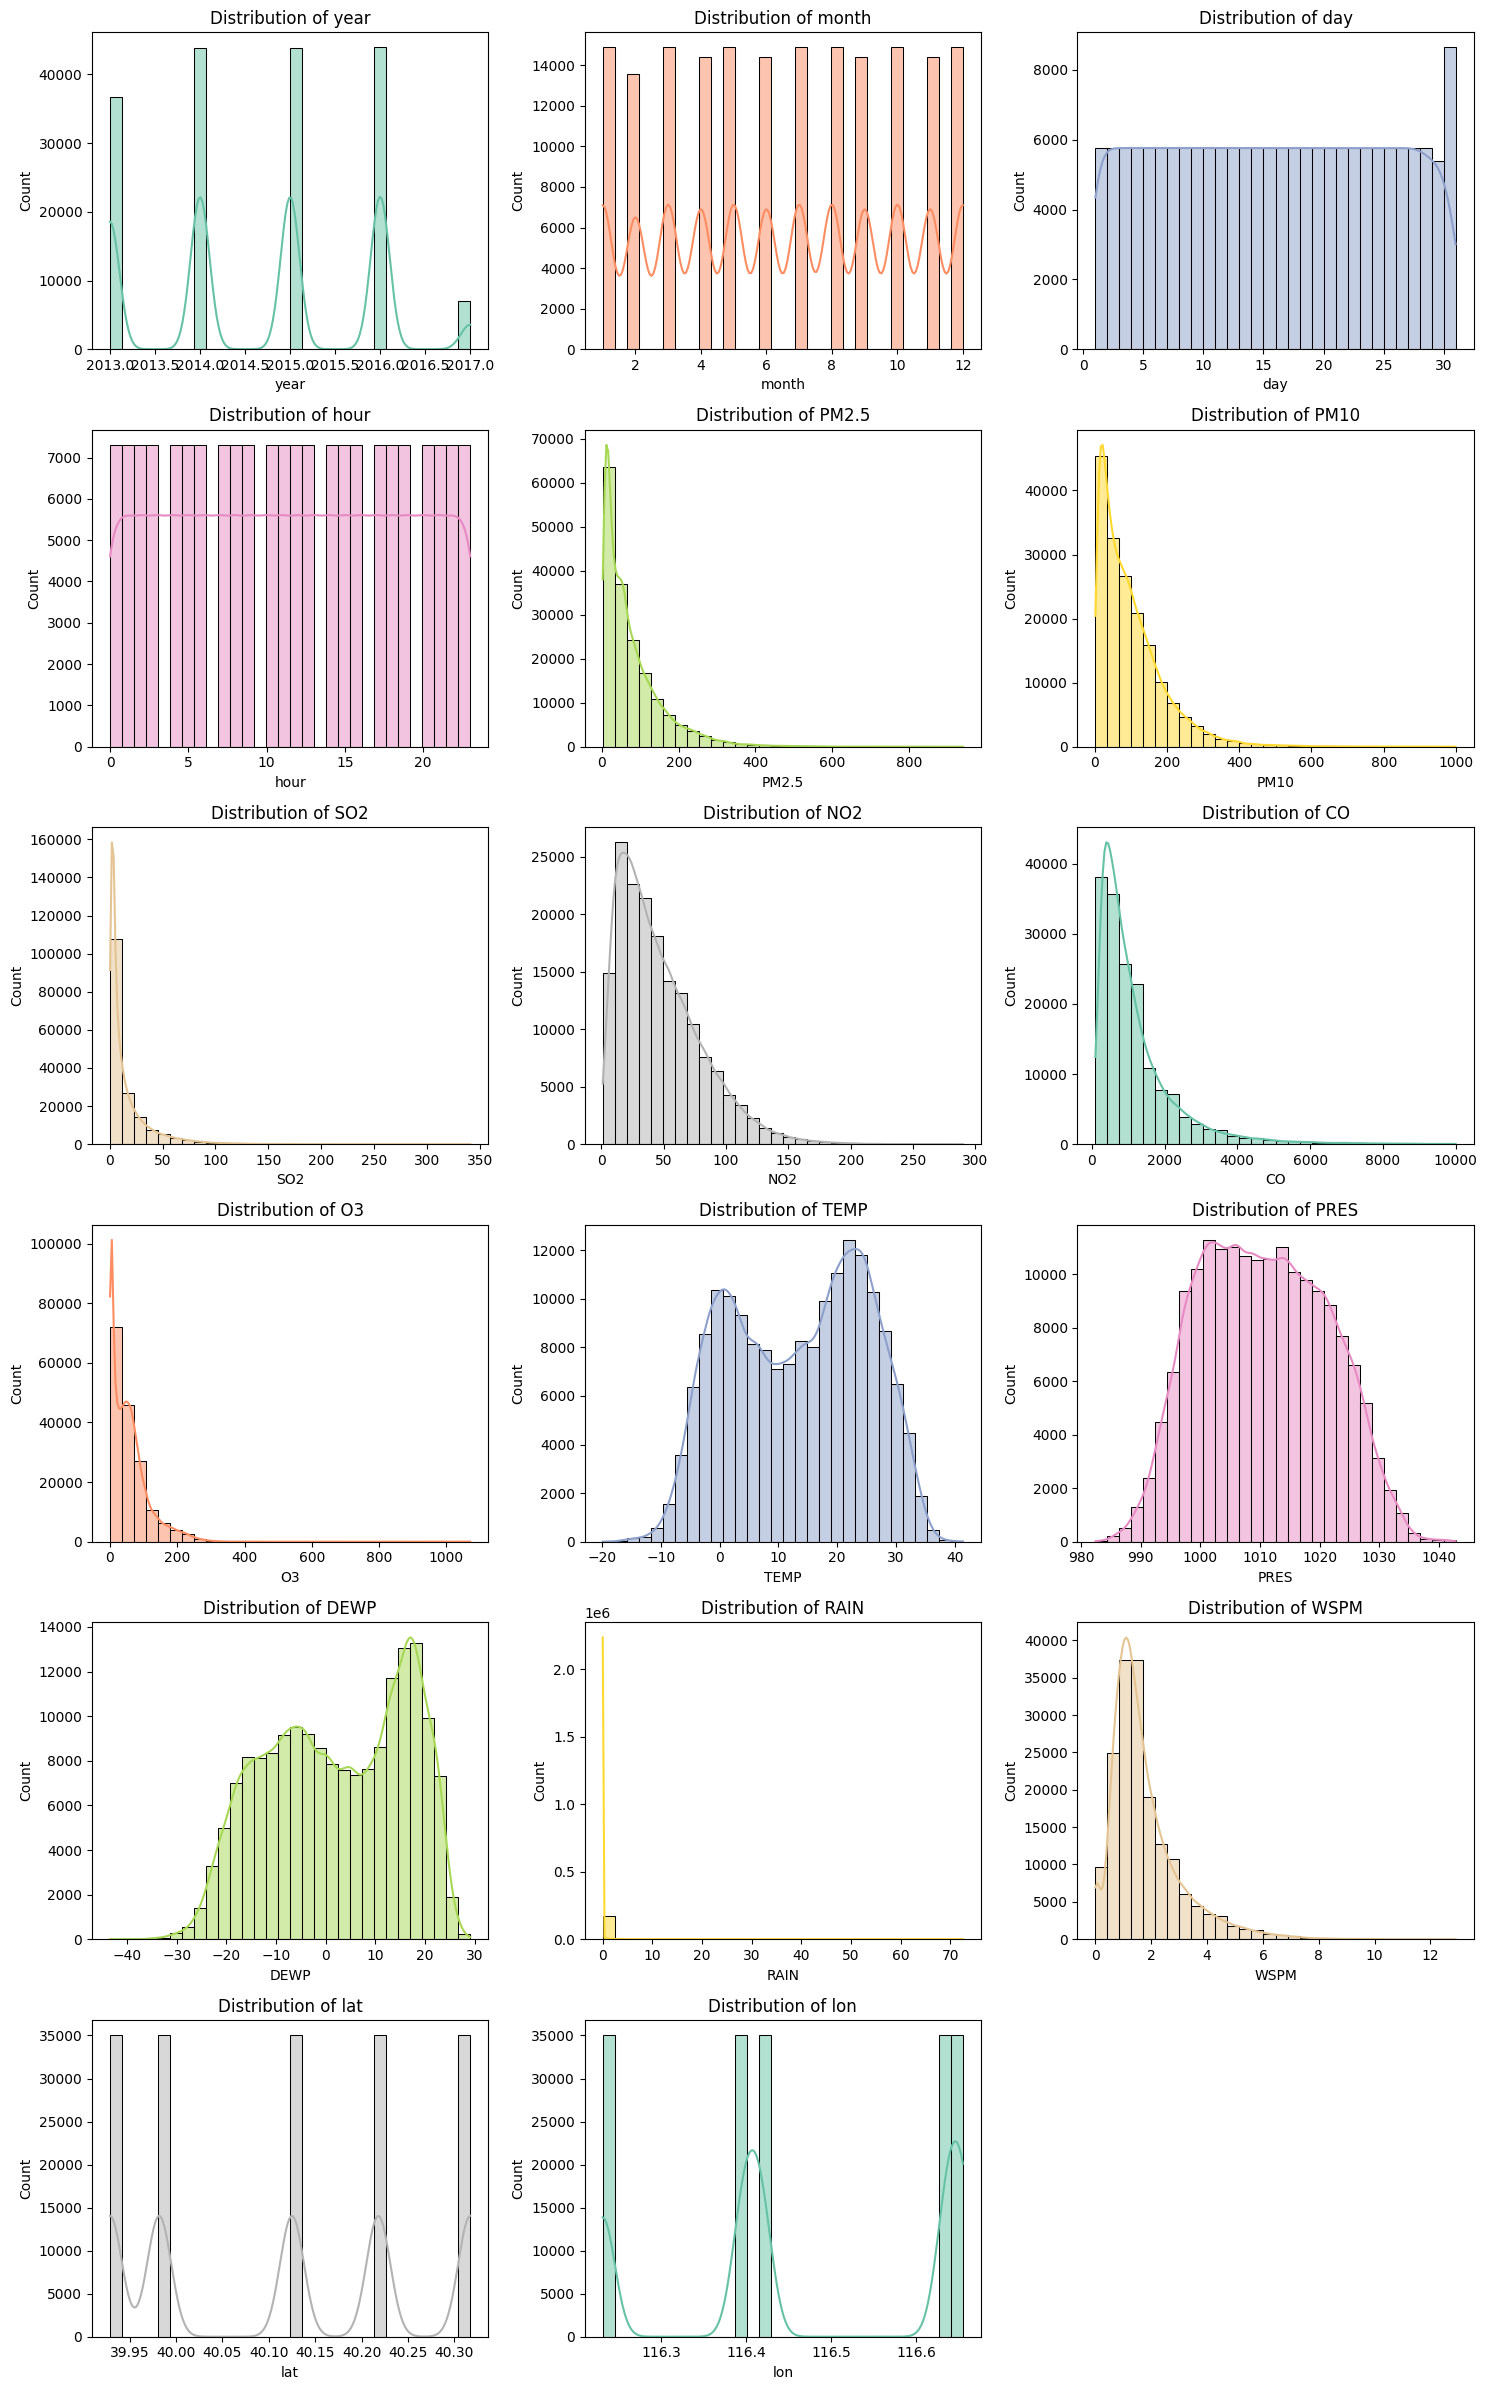

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns

num_features = len(numerical_cols)
num_rows = int(np.ceil(num_features / 3))

colors = sns.color_palette('Set2', n_colors=num_features)

plt.figure(figsize=(15, num_rows * 4))
for i, (col, color) in enumerate(zip(numerical_cols, colors), 1):
    plt.subplot(num_rows, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color=color)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

To visualize the distribution of air quality categories, I created a pie chart showing the percentage of each `PM2.5_category`.

I used color coding to clearly distinguish each category, and exploded the 'Medium' slice to emphasize the most frequent level. This visualization gives a quick overview of how often each air quality condition occurs in the data.



This pie chart visualizes the overall distribution of PM2.5 air quality levels across all stations and time periods.

## Key Observations
1. **Low Pollution**: Comprises the largest segment at **37.7%** of all observations
   - This indicates that good air quality conditions occur most frequently
   - Likely corresponds to values below official Chinese AQI thresholds for low concern

2. **High Pollution**: Represents **37.2%** of the dataset
   - Nearly equal to the Low category, suggesting Beijing experiences severe pollution episodes at a frequency almost matching good air quality days
   - This substantial portion highlights the significant air quality challenges in the region

3. **Medium Pollution**: Accounts for **25.2%** of observations
   - The smallest category, indicating pollution levels tend to polarize toward either low or high conditions
   - Transitional states occur less frequently than the extremes

  
## Health and Policy Relevance
- The nearly equal distribution between Low and High categories suggests that Beijing residents experience both healthy and unhealthy air quality with similar frequency
- The significant proportion of High pollution episodes (37.2%) requires the continuing need for air quality improvement policies
- Seasonal or temporal analysis may reveal patterns in when these different categories occur


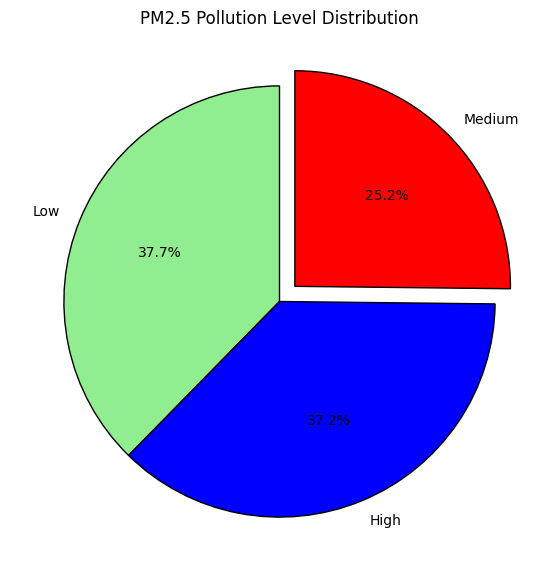

In [ ]:
weather = df['PM2.5_category'].value_counts()
labels = weather.index.tolist()

color_map = {'Low': 'lightgreen', 'Medium': 'red', 'High': 'blue'}
colors = [color_map[label] for label in labels]


plt.figure(figsize=(7, 7))
plt.pie(weather, labels=labels, autopct='%1.1f%%', colors=colors,
        explode=[0.1 if label == 'Medium' else 0 for label in labels],
        startangle=90, wedgeprops={'edgecolor': 'black'})

plt.title('PM2.5 Pollution Level Distribution')
plt.show()



# PM2.5 Distribution by Area Type

Looking at the bar chart showing pollution levels across different areas of Beijing, I noticed some fascinating patterns that challenge conventional assumptions about urban air quality.

## Urban vs. Rural Pollution Dynamics

What immediately jumped out at me was how the Urban areas showed the highest levels of "High" category pollution (around 14,500 instances), which wasn't surprising. But I didn't expect to see that Rural areas would follow with similarly elevated counts of "High" pollution events. This suggests that poor air quality isn't just limited to the urban side.

The Suburban areas actually recorded the highest frequency of "Low" pollution readings (approximately 14,500 counts), even exceeding Rural areas. This contradicts what I initially expected and indicates that some suburban zones might benefit from favorable geographic positioning or wind patterns.

## Consistency in Medium Category

I found it interesting that the "Medium" pollution category remains remarkably consistent across all area types - hovering around 9,000 counts regardless of location. This stability across different environments suggests that moderate pollution levels might be influenced by regional rather than local factors.

## Industrial Areas: Not the Worst Offenders

Counter to what I anticipated, Industrial zones didn't show the highest pollution readings. They displayed a more balanced profile between the three categories compared to Urban areas. This might reflect the impact of targeted emission controls in industrial zones or potentially indicate that vehicle emissions in dense urban areas are more significant contributors than industrial sources.

## Implications for Residents and Policy

For Beijing residents, these findings suggest that relocating to Rural or Semi-Rural areas may not necessarily guarantee better air quality. The data shows that pollution is a regional issue that transcends simple urban-rural divides.



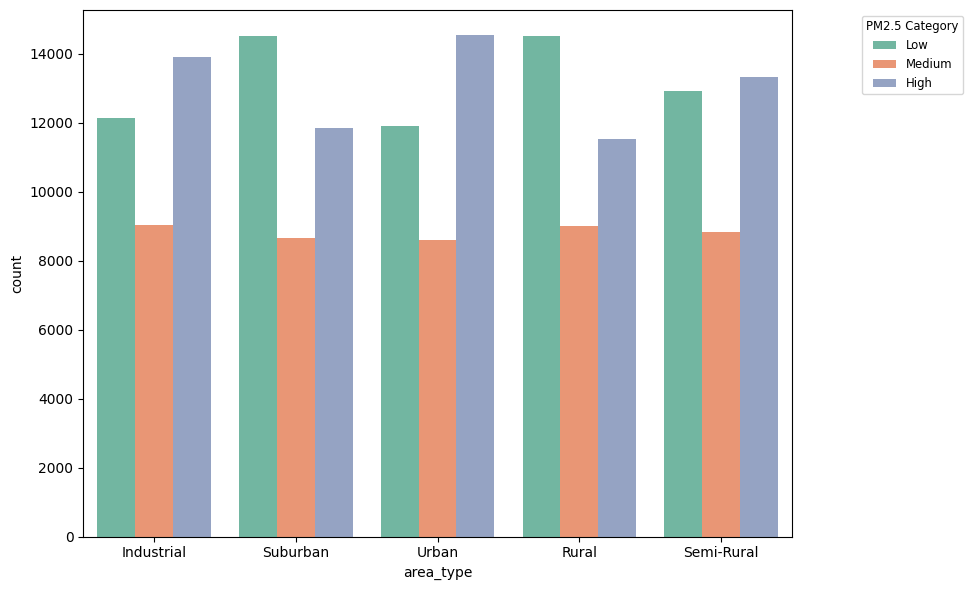

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='area_type', hue='PM2.5_category', palette='Set2')

plt.legend(title='PM2.5 Category', fontsize='small', title_fontsize='small',
        loc='upper right', bbox_to_anchor=(1.25, 1))

plt.tight_layout()
plt.show()

In [ ]:
df.head(3)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,DEWP,RAIN,wd,WSPM,station,area_type,lat,lon,PM2.5_category,date
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,...,-18.8,0.0,NNW,4.4,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,...,-18.2,0.0,N,4.7,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,...,-18.2,0.0,NNW,5.6,Aotizhongxin,Industrial,39.982,116.397,Low,2013-03-01


### Geographical Disadvantage EDA

This section focuses on analyzing how air pollution levels vary depending on the geographical classification of each monitoring station — specifically, whether it's located in an Urban, Suburban, Rural, Industrial, or Semi-Rural area.

## Distribution Patterns Across Area Types

Looking at the boxplot distribution of PM2.5 across different area types, several key patterns emerge:

1. **Urban Penalty**: Urban areas show the highest median PM2.5 concentration (~70 μg/m³), confirming that city centers bear a disproportionate pollution burden. This "urban penalty" likely results from concentrated vehicle emissions, building density, and reduced airflow in street canyons.

2. **Semi-Rural Surprise**: Counter to what might be expected, Semi-Rural areas display the second-highest median concentration, suggesting pollution doesn't simply decrease with distance from urban centers. This may reflect topographical trapping of pollutants or proximity to peripheral industrial zones.

3. **Outlier Episodes**: All area types experience extreme pollution episodes exceeding 600 μg/m³, with Semi-Rural and Industrial zones recording the most severe outliers (approaching 900 μg/m³). These extreme episodes appear independent of area classification.

4. **Suburban Advantage**: Suburban areas show the lowest median PM2.5 levels, potentially benefiting from intermediate positioning that avoids both urban emission sources and regional pollution transport patterns affecting rural areas.


These visualizations clearly show that geographical location significantly impacts air quality — with **industrial and urban areas generally facing worse conditions**, while **rural and suburban zones tend to experience better air quality**. However, even rural areas occasionally show high spikes, likely due to seasonal or wind-based factors.


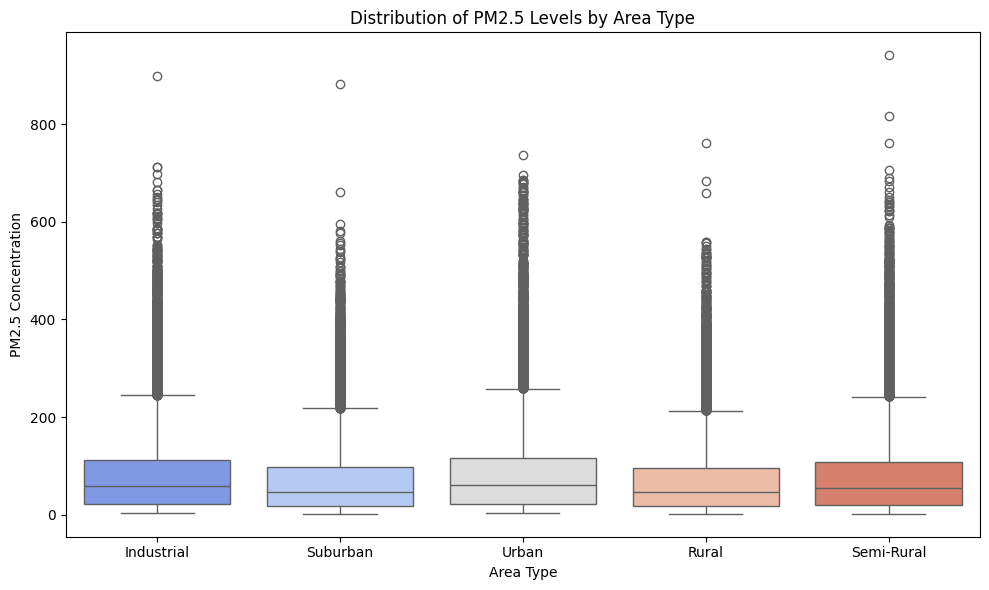

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='area_type', y='PM2.5', palette='coolwarm')
plt.title('Distribution of PM2.5 Levels by Area Type')
plt.xlabel('Area Type')
plt.ylabel('PM2.5 Concentration')
plt.tight_layout()
plt.show()


# PM2.5 and PM10 Geographic Disparity in Beijing

This bar chart reveals a clear geographic disadvantage in air quality exposure across Beijing, where residents of certain areas face significantly higher particulate matter concentrations through no choice of their own - a systemic environmental inequity embedded in the urban geography.

## Urban-Rural Pollution Gradient

The most striking pattern in this visualization is the consistent decrease in both PM2.5 and PM10 concentrations as we move from Urban/Industrial to Rural areas:

1. **Urban-Industrial Dominance**: Urban (approx 85 μg/m³) and Industrial (approx 82 μg/m³) areas show the highest average PM2.5 concentrations, exceeding the Rural average by approximately 15-18 μg/m³. This represents roughly 25% higher exposure for city dwellers compared to rural residents.

2. **PM10 Pattern Confirmation**: The PM10 data reinforces this spatial pattern, with Urban and Industrial zones experiencing concentrations above 110 μg/m³, while Rural areas average around 90 μg/m³.

3. **Semi-Rural Transition**: Semi-Rural areas display intermediate pollution levels (~79 μg/m³ for PM2.5), functioning as a transition zone between urban and rural environments.

4. **Suburban Advantage**: Suburban areas show lower PM2.5 levels (~70 μg/m³) than their Semi-Rural counterparts, possibly benefiting from targeted environmental protection measures or favorable topographical positioning.

## PM2.5/PM10 Ratio Insights

An interesting secondary observation is the PM2.5/PM10 ratio across different area types:

- Rural areas show the lowest ratio (~0.77), suggesting a higher proportion of coarse particles likely from natural dust and agricultural activities
- Urban areas display the highest ratio (~0.79), indicating a greater fraction of fine particles typical of combustion sources like vehicles and heating

This aligns with findings from (Wang and Zhang, 2020), who noted that "the ratio of PM2.5/PM10 in urban Beijing was consistently higher than in surrounding areas, reflecting the predominance of fine particle emissions from anthropogenic sources in dense urban environments."

## Implications for Health and Policy

These findings have significant public health implications. The average PM2.5 concentration exceeds 70 μg/m³ across all area types - far above the WHO guideline of 5 μg/m³. However, the ~18 μg/m³ difference between Urban and Rural areas translates to approximately 10-15% higher long-term mortality risk for urban residents based on established concentration-response functions.

As noted by (Hu et al., 2023), "an increase of 10 μg/m³ in PM2.5 was associated with a 7.3% increase in all-cause mortality across Chinese cities." This suggests that the geographic disparity observed here has tangible health consequences for Beijing's urban population.

(Xu et al., 2019) further emphasized that "residential proximity to industrial zones in Beijing was associated with significantly elevated PM2.5 exposure and corresponding increases in respiratory hospitalizations, creating an environmental justice concern." Our visualization provides quantitative support for this environmental inequality across Beijing's diverse geographic zones.

---

**References:**
- Hu, J. et al. (2023) ‘Long-Term Exposure to PM2.5 and Mortality: A Cohort Study in China’, Toxics, 11(9), p. 727. Available at: https://doi.org/10.3390/toxics11090727.
- Xu, Y. et al. (2019) ‘Unraveling environmental justice in ambient PM2.5 exposure in Beijing: A big data approach’, Computers, Environment and Urban Systems, 75, pp. 12–21. Available at: https://doi.org/10.1016/j.compenvurbsys.2018.12.006.
- Wang, X. and Zhang, R. (2020) ‘Effects of atmospheric circulations on the interannual variation in PM2.5 concentrations over the Beijing–Tianjin–Hebei region in 2013–2018’, Atmospheric Chemistry and Physics, 20(13), pp. 7667–7682. Available at: https://doi.org/10.5194/acp-20-7667-2020.

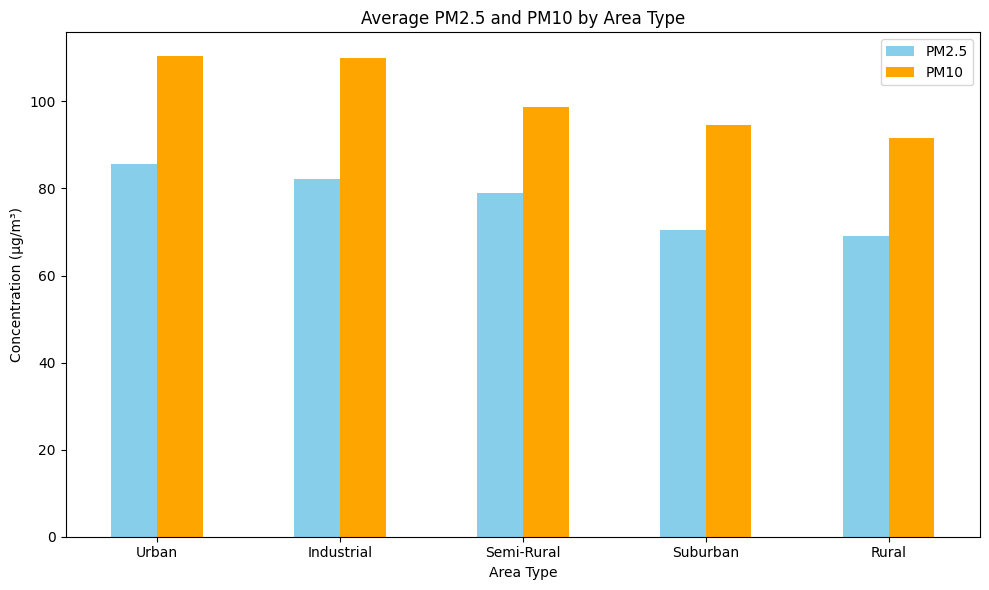

In [ ]:
pollution_means = df.groupby('area_type')[['PM2.5', 'PM10']].mean().sort_values(by='PM2.5', ascending=False)

pollution_means.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'])
plt.title('Average PM2.5 and PM10 by Area Type')
plt.ylabel('Concentration (µg/m³)')
plt.xlabel('Area Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Seasonal Variation of PM2.5 Levels Across Different Area Types in Beijing

This visualization reveals the complex interplay between seasonal meteorology and geographic location, demonstrating how both temporal and spatial factors combine to create variable pollution exposure patterns across Beijing's diverse areas.

## Seasonal Patterns

The most significant pattern in this data is the pronounced seasonality of PM2.5 concentrations across all area types:

1. **Winter Pollution Crisis**: Winter shows dramatically elevated PM2.5 levels across all regions, with urban areas reaching a concerning average of ~102 μg/m³. This aligns with research by (Wang et al., 2019), who noted that "winter PM2.5 concentrations in Beijing frequently exceed 100 μg/m³ due to increased coal combustion for heating and unfavorable meteorological conditions including temperature inversions that trap pollutants near the surface"

2. **Summer Minimum**: Summer shows the lowest PM2.5 concentrations (55-70 μg/m³) across all area types. This seasonal improvement can be attributed to what (Liu et al., 2018) described as "enhanced vertical mixing, increased precipitation scavenging, and reduced emissions from heating sources during summer months in North China"

3. **Transitional Seasons**: Spring and autumn show intermediate levels, with autumn generally higher than spring across all areas.

## Geographic Disparities Persist Across Seasons

A critical observation is that the relative ranking of area types remains mostly consistent across seasons:

1. **Urban Vulnerability**: Urban areas consistently show among the highest PM2.5 levels in all seasons, with the urban-rural gap widening most dramatically in winter (~20 μg/m³ difference).

2. **Industrial Areas**: Industrial zones show high PM2.5 in winter (95 μg/m³) and remain elevated even in summer (65 μg/m³). This pattern supports findings by (Zheng et al., 2017) who reported that "industrial emissions contribute significantly to Beijing's PM2.5 burden throughout the year, but their proportional impact is greater during summer when heating-related emissions decrease"

3. **Suburban Advantage**: Suburban areas consistently maintain lower PM2.5 levels than both urban and industrial zones across all seasons, suggesting structural advantages in these intermediate locations.

## Geographic Resilience to Seasonal Effects

The data reveals interesting differences in seasonal vulnerability:

1. **Highest Seasonal Amplitude**: Urban areas show the largest seasonal swing (~40 μg/m³ difference between summer and winter), supporting (Xing, Mao and Duan, 2022) who found that "urban centers in Beijing experience more extreme seasonal variations in PM2.5 compared to surrounding areas due to intensified winter heating emissions and canyon effects that trap pollutants"

2. **Rural Stability**: Rural areas show the most moderate seasonal changes, maintaining relatively consistent (though still unhealthy) PM2.5 levels year-round.

## Health and Policy Implications

These findings have significant implications for seasonal environmental justice. As noted by (Lei et al., 2022), "the combination of geographic and seasonal disparities in air pollution exposure creates compounded vulnerability for urban residents during winter months, with average exposure exceeding WHO guidelines by more than 20-fold"





>**References:**
- Lei, R. et al. (2022) ‘Spatial and temporal characteristics of air pollutants and their health effects in China during 2019–2020’, Journal of Environmental Management, 317, p. 115460. Available at: https://doi.org/10.1016/j.jenvman.2022.115460.
- Liu, H. et al. (2018) ‘Ground-level ozone pollution and its health impacts in China’, Atmospheric Environment, 173, pp. 223–230. Available at: https://doi.org/10.1016/j.atmosenv.2017.11.014.
- Wang, Y. et al. (2019) ‘Trends in particulate matter and its chemical compositions in China from 2013–2017’, Science China. Earth Sciences/Science China. Earth sciences, 62(12), pp. 1857–1871. Available at: https://doi.org/10.1007/s11430-018-9373-1.
- Xing, L., Mao, X. and Duan, K. (2022) ‘Impacts of urban–rural disparities in the trends of PM2.5 and ozone levels in China during 2013–2019’, Atmospheric Pollution Research, 13(11), p. 101590. Available at: https://doi.org/10.1016/j.apr.2022.101590.
- Zheng, Y. et al. (2017) ‘Air quality improvements and health benefits from China’s clean air action since 2013’, Environmental Research Letters, 12(11), p. 114020. Available at: https://doi.org/10.1088/1748-9326/aa8a32.

In [ ]:
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

df['season'] = df['month'].map(season_map)

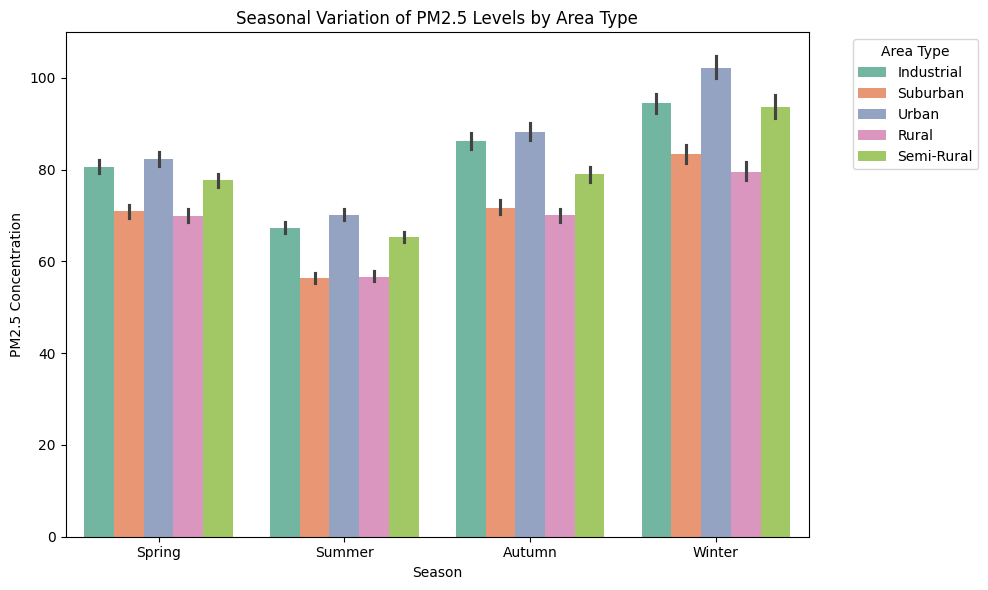

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='season', y='PM2.5', hue='area_type', palette='Set2')
plt.title('Seasonal Variation of PM2.5 Levels by Area Type')
plt.xlabel('Season')
plt.ylabel('PM2.5 Concentration')
plt.legend(title='Area Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Monthly Trends of Key Pollutants: SO2, NO2, CO, and O3

The plot displays the monthly median levels of four significant pollutants: SO2, NO2, CO, and O3, providing a comprehensive overview of their seasonal patterns.

#### Observations:

- **SO2:** Elevated concentrations are observed in the winter months, notably in **January, February, and December**, suggesting increased emissions from heating and lower atmospheric dispersion (Wang et al., 2014).
- **NO2:** Peaks during **January, February, and the late fall months (October to December)**, which may be attributed to heightened vehicular emissions and domestic heating during the colder months (Zheng et al., 2018).
- **CO:** Similarly, CO levels are higher in **January, February, and December**, indicating a correlation with fossil fuel burning for heating and potential traffic emissions (Li et al., 2017).
- **O3:** In contrast to SO2, NO2, and CO, O3 levels reach their maximum in the warmer months, particularly **April to July**, due to increased photochemical reactions under higher sunlight (Li et al., 2017).

#### Conclusion:

The analysis underscores that while SO2, NO2, and CO show higher concentrations in colder months, influenced by anthropogenic activities, O3 demonstrates a distinct pattern peaking in warmer months due to natural atmospheric processes (Wang et al., 2014). These findings highlight that **pollutant levels are uniquely impacted by seasonal and meteorological factors**, necessitating distinct mitigation strategies for each pollutant and season.

### References

- Wang, Y. et al. (2014) ‘Spatial and temporal variations of six criteria air pollutants in 31 provincial capital cities in China during 2013–2014’, Environment International, 73, pp. 413–422. Available at: https://doi.org/10.1016/j.envint.2014.08.016.

- Zheng, B. et al. (2018) ‘Trends in China’s anthropogenic emissions since 2010 as the consequence of clean air actions’, Atmospheric Chemistry and Physics, 18(19), pp. 14095–14111. Available at: https://doi.org/10.5194/acp-18-14095-2018.

- Li, K. et al. (2017) ‘Meteorological and chemical impacts on ozone formation: A case study in Hangzhou, China’, Atmospheric Research, 196, pp. 40–52. Available at: https://doi.org/10.1016/j.atmosres.2017.06.003.

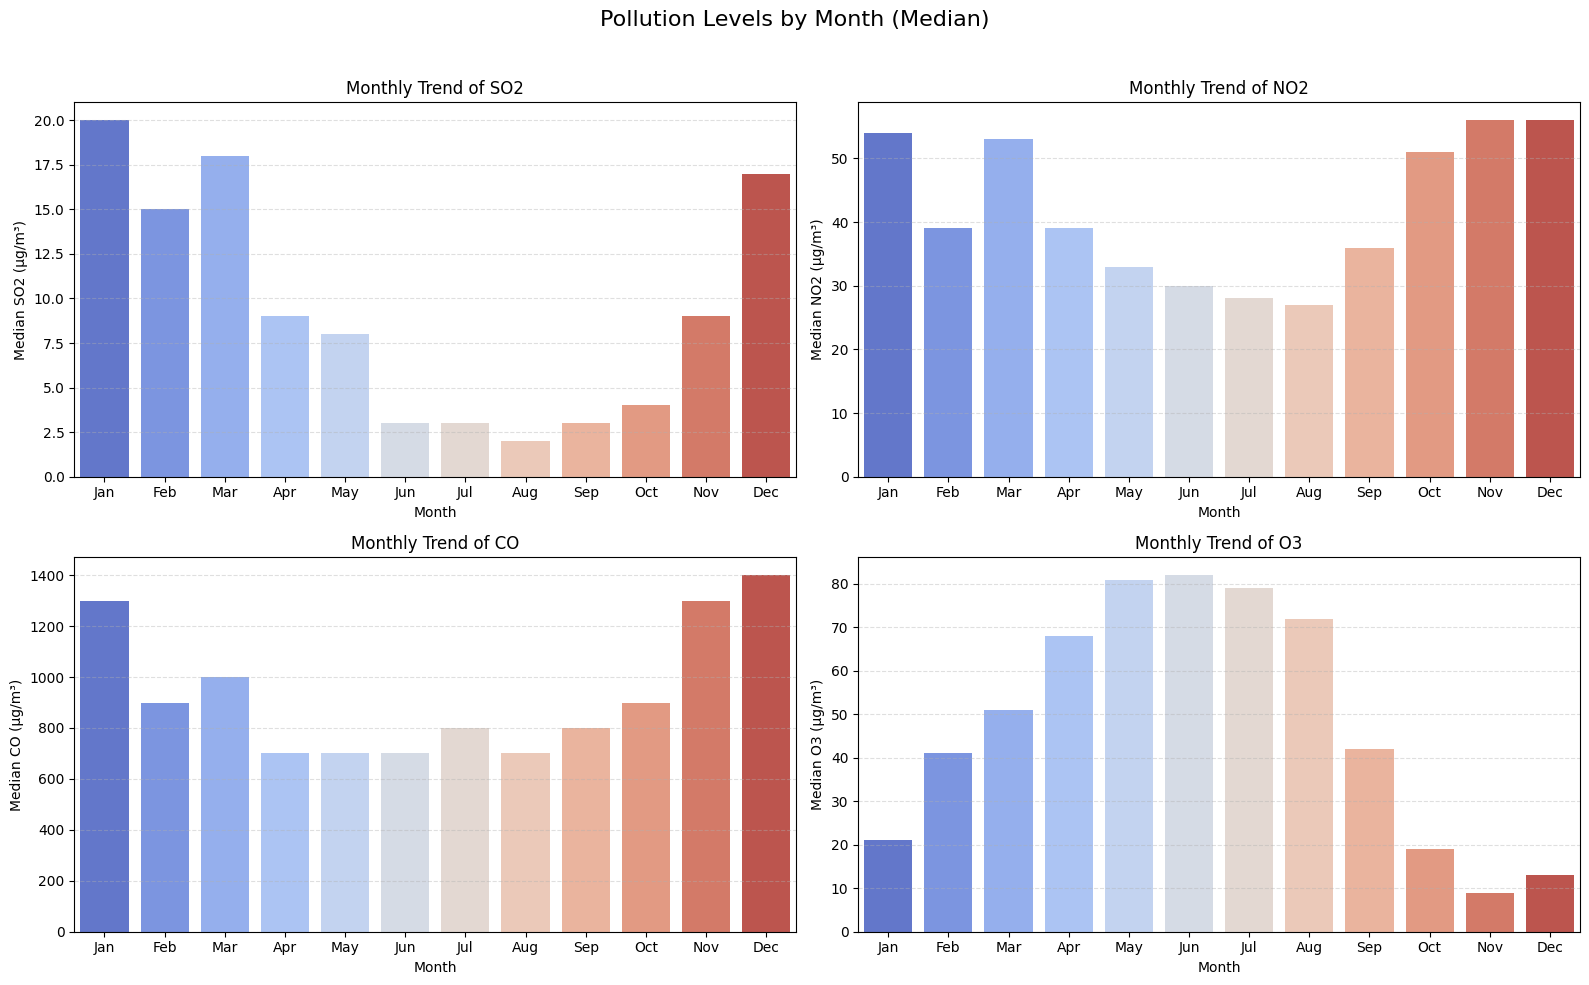

In [ ]:
plt.figure(figsize=(16, 10))
pollutants = ['SO2', 'NO2', 'CO', 'O3']
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, col in enumerate(pollutants, 1):
    ax = plt.subplot(2, 2, i)
    sns.barplot(x='month', y=col, data=df, palette='coolwarm',
                estimator=np.median, ci=None, ax=ax)
    ax.set_title(f'Monthly Trend of {col}')
    ax.set_xlabel('Month')
    ax.set_ylabel(f'Median {col} (µg/m³)')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_labels)

plt.suptitle('Pollution Levels by Month (Median)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
df.columns

Index(['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO',
       'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'area_type', 'lat', 'lon', 'PM2.5_category', 'date', 'season'],
      dtype='object')

### Feature Engineering

To extract more meaning from the raw dataset and help our model better understand air pollution patterns, I engineered several new features based on scientific reasoning and environmental knowledge:

1. **temp_dewp_diff**: The difference between temperature and dew point, which indicates humidity. A smaller gap suggests more atmospheric moisture, leading to more suspended particulate matter.

2. **inverse_wind**: Since strong winds disperse pollution, this feature emphasizes stagnant air conditions where pollution builds up. It is calculated as the inverse of wind speed.

3. **night_time**: A binary flag marking late-night hours (before 6 AM or after 9 PM). These hours often have less traffic but more pollution retention due to stable atmospheric layers.

4. **Rain_Flag**: Indicates whether it was raining or not. Rain can help clean the air, reducing PM2.5 and PM10 by washing particles out of the atmosphere.

5. **CO_NO2_ratio**: This ratio reflects traffic-related pollution. CO is generally from incomplete combustion, while NO2 spikes in high-traffic zones.

By transforming the raw environmental readings into meaningful indicators, this feature engineering step enhances the model's ability to detect patterns, especially those tied to **geographical disadvantage**, **weather effects**, and **daily human activity**.


In [ ]:
# 1. Temperature and Dew Point Difference
df['temp_dewp_diff'] = df['TEMP'] - df['DEWP']

# 2. Inverse Wind Speed – this is good parameter to analyse, as high value means still air, likely to trap pollutants
df['inverse_wind'] = 1 / (df['WSPM'] + 0.1)

# 3. Night Time Indicator – we take this to check the pollution indicator as pollution might settle at night due to low wind and no sun
df['night_time'] = df['hour'].apply(lambda x: 1 if x < 6 or x >= 21 else 0)

# 4. Rain Flag – rain helps clean the air, may lower PM2.5
df['Rain_Flag'] = df['RAIN'].apply(lambda x: 1 if x > 0 else 0)

df['CO_NO2_ratio'] = df['CO'] / (df['NO2'] + 0.1)


df.drop(['TEMP', 'DEWP', 'WSPM', 'RAIN', 'hour', 'PM2.5'], axis=1, inplace=True)

In [ ]:
df.head(1).T

,0
year,2013
month,3
day,1
PM10,4.0
SO2,4.0
NO2,7.0
CO,300.0
O3,77.0
PRES,1023.0
wd,NNW


### Data Preprocessing: Handling Missing Values

To prepare the dataset for modeling, I checked for missing values in both numerical and categorical columns.

- For numeric features like `PM10`, `SO2`, `NO2`, etc., I used the **median** to fill missing values. Median imputation is robust to outliers and helps maintain the distribution of the data.
- For the wind direction (`wd`), which is categorical, I used the **mode**, i.e., the most frequently occurring wind direction.

After imputation, I rechecked for missing values and confirmed that the dataset is now clean and ready for further analysis or modeling.


In [ ]:
df.isnull().sum()

,0
year,0
month,0
day,0
PM10,3178
SO2,4502
NO2,6295
CO,10094
O3,5627
PRES,194
wd,1084


In [ ]:
for label,content in df.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      print(label)

PM10
SO2
NO2
CO
O3
PRES
temp_dewp_diff
inverse_wind
CO_NO2_ratio


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175320 entries, 0 to 175319
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   year            175320 non-null  int64         
 1   month           175320 non-null  int64         
 2   day             175320 non-null  int64         
 3   PM10            172142 non-null  float64       
 4   SO2             170818 non-null  float64       
 5   NO2             169025 non-null  float64       
 6   CO              165226 non-null  float64       
 7   O3              169693 non-null  float64       
 8   PRES            175126 non-null  float64       
 9   wd              174236 non-null  object        
 10  station         175320 non-null  object        
 11  area_type       175320 non-null  object        
 12  lat             175320 non-null  float64       
 13  lon             175320 non-null  float64       
 14  PM2.5_category  175320 non-null  obj

# **Treating Missing Values**

In [ ]:
df['PM10'].fillna(df['SO2'].median(), inplace=True)
df['SO2'].fillna(df['SO2'].median(),inplace=True)
df['NO2'].fillna(df['NO2'].median(), inplace=True)
df['CO'].fillna(df['CO'].median(), inplace=True)
df['O3'].fillna(df['O3'].median(), inplace=True)
df['PRES'].fillna(df['PRES'].median(), inplace=True)
df['temp_dewp_diff'].fillna(df['temp_dewp_diff'].median(), inplace=True)
df['inverse_wind'].fillna(df['inverse_wind'].median(), inplace=True)

df['wd'].fillna(df['wd'].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

,0
year,0
month,0
day,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
PRES,0
wd,0


### 🔄 Target Encoding & Data Cleaning

To prepare for modeling, I performed the following preprocessing steps:

#### 🎯 1. Target Encoding
The PM2.5 pollution categories (e.g., Good, Moderate, Unhealthy) were encoded into numerical labels (0–4) using `LabelEncoder`. This is required for classification models to work with categorical targets.

#### ✂️ 2. Dropping Redundant Columns
The `year` and `day` columns were removed, as they do not contribute much to the model once we’ve already included season and month.

#### 🔍 3. Duplicate Check
I checked for and counted duplicate rows based on all major input features. While no duplicates were removed at this stage, this check helps validate the uniqueness of records.









In [ ]:
le = LabelEncoder()
df['PM2.5_category_encoded'] = le.fit_transform(df['PM2.5_category'])

df.drop(columns=['PM2.5_category'],inplace=True)

In [ ]:
df['PM2.5_category_encoded'].value_counts()

,count
PM2.5_category_encoded,
1,66020
0,65158
2,44142


In [ ]:
df.head(1)

,year,month,day,PM10,SO2,NO2,CO,O3,PRES,wd,...,lat,lon,date,season,temp_dewp_diff,inverse_wind,night_time,Rain_Flag,CO_NO2_ratio,PM2.5_category_encoded
0,2013,3,1,4.0,4.0,7.0,300.0,77.0,1023.0,NNW,...,39.982,116.397,2013-03-01,Spring,18.1,0.222222,1,0,42.253521,1


## Dropping columns to avoid unnecessary complexity based on feature importance

In [ ]:
df.drop(columns=['year', 'day','area_type','lat','lon','date','season'], inplace=True)

# Checking for Duplicated rows

In [ ]:
duplicate_count = df.duplicated(subset=['PM10','SO2','NO2','CO','O3','PRES','station','wd','temp_dewp_diff','inverse_wind','night_time'],).sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


# Splitting data apply transformation such as Encoding and Log Transformation

In [ ]:
X = df.drop('PM2.5_category_encoded', axis=1)
y = df['PM2.5_category_encoded']

In [ ]:
np.random.seed(42)


X_sampled, _, y_sampled, _ = train_test_split(
    X, y,
    train_size=60000,
    stratify=y,
    random_state=42
)

# Train-test split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_sampled, y_sampled,
    test_size=0.2,
    stratify=y_sampled,
    random_state=42
)

print(f"Sampled X shape: {X_sampled.shape}")
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts()}")

Sampled X shape: (60000, 14)
Train size: (48000, 14), Test size: (12000, 14)
Train class distribution:
PM2.5_category_encoded
1    18075
0    17839
2    12086
Name: count, dtype: int64


# Log Normal Transformation for Data Skew

# 🔄 Analysis of Log Transformation on Beijing Air Pollution Data

The following analysis examines the effect of applying **logarithmic transformation** to key air pollution parameters in the Beijing dataset. This transformation is a critical preprocessing step, especially for highly skewed data, enabling better statistical modeling and visualization.

---

## 📈 Key Observations

### 1. **Highly Skewed Distributions Normalized**

- **Original distributions** (left column): Most pollutants (PM10, CO, O₃, SO₂, NO₂) exhibit extreme **right-skewed** distributions, with many observations clustered at low values and long tails toward higher concentrations.
- **Log-transformed distributions** (right column): After transformation, the data appears more **symmetrical**, often **bell-shaped**, and better approximates **normal distributions**.

---

### 2. **Parameter-Specific Improvements**

- **PM10**  
  - Original: Heavily concentrated below 200 μg/m³ with extreme outliers.  
  - Log: More balanced distribution centered around **4–5 log units**.

- **CO (Carbon Monoxide)**  
  - Original: Strongly skewed to lower values.  
  - Log: Data spreads more evenly across **6–8 log units**.

- **O₃ (Ozone)**  
  - Original: Uneven pattern.  
  - Log: Reveals a **bimodal distribution**, suggesting different environmental conditions.

- **SO₂ (Sulfur Dioxide)**  
  - Original: Extreme concentration near zero.  
  - Log: Shows a peak near **1 log unit**, with a secondary spread at higher levels.

- **NO₂ (Nitrogen Dioxide)**  
  - Original: Skewed to the right.  
  - Log: Becomes **more symmetric**, centered around **4 log units**.

- **PM2.5**  
  - Original: Already relatively balanced.  
  - Log: Enhances symmetry further, improving model readiness.

---

## 📊 Statistical and Analytical Advantages of Log Transformation

- ✅ **Improved model performance**  
  Many machine learning algorithms work better with data that is normally distributed.

- ✅ **Enhanced visualization**  
  Log-transformed data reveals **hidden patterns** that may be obscured in skewed data.

- ✅ **Reduced outlier impact**  
  Extreme pollution events no longer **dominate the distribution**.

- ✅ **Consistent scale**  
  Different pollutants are brought to a **comparable scale**, which helps in **multi-feature modeling**.

- ✅ **Linearized relationships**  
  Multiplicative or exponential relationships may become **linear**, making them easier to model statistically.

---


Log transformation is especially useful in air pollution datasets like Beijing's, where extreme values and non-linearity are common. This transformation enables:

- More robust statistical testing  
- Improved model accuracy  
- Cleaner visualizations across different stations and conditions

It is a **critical step in our preprocessing pipeline** for accurate and interpretable air quality analysis.


In [ ]:
log_vars = ['PM10', 'CO', 'O3', 'SO2', 'NO2', 'PRES', 'temp_dewp_diff', 'inverse_wind']

for col in log_vars:
    X_train[col + "_log"] = np.log1p(X_train[col])
    X_test[col + "_log"] = np.log1p(X_test[col])

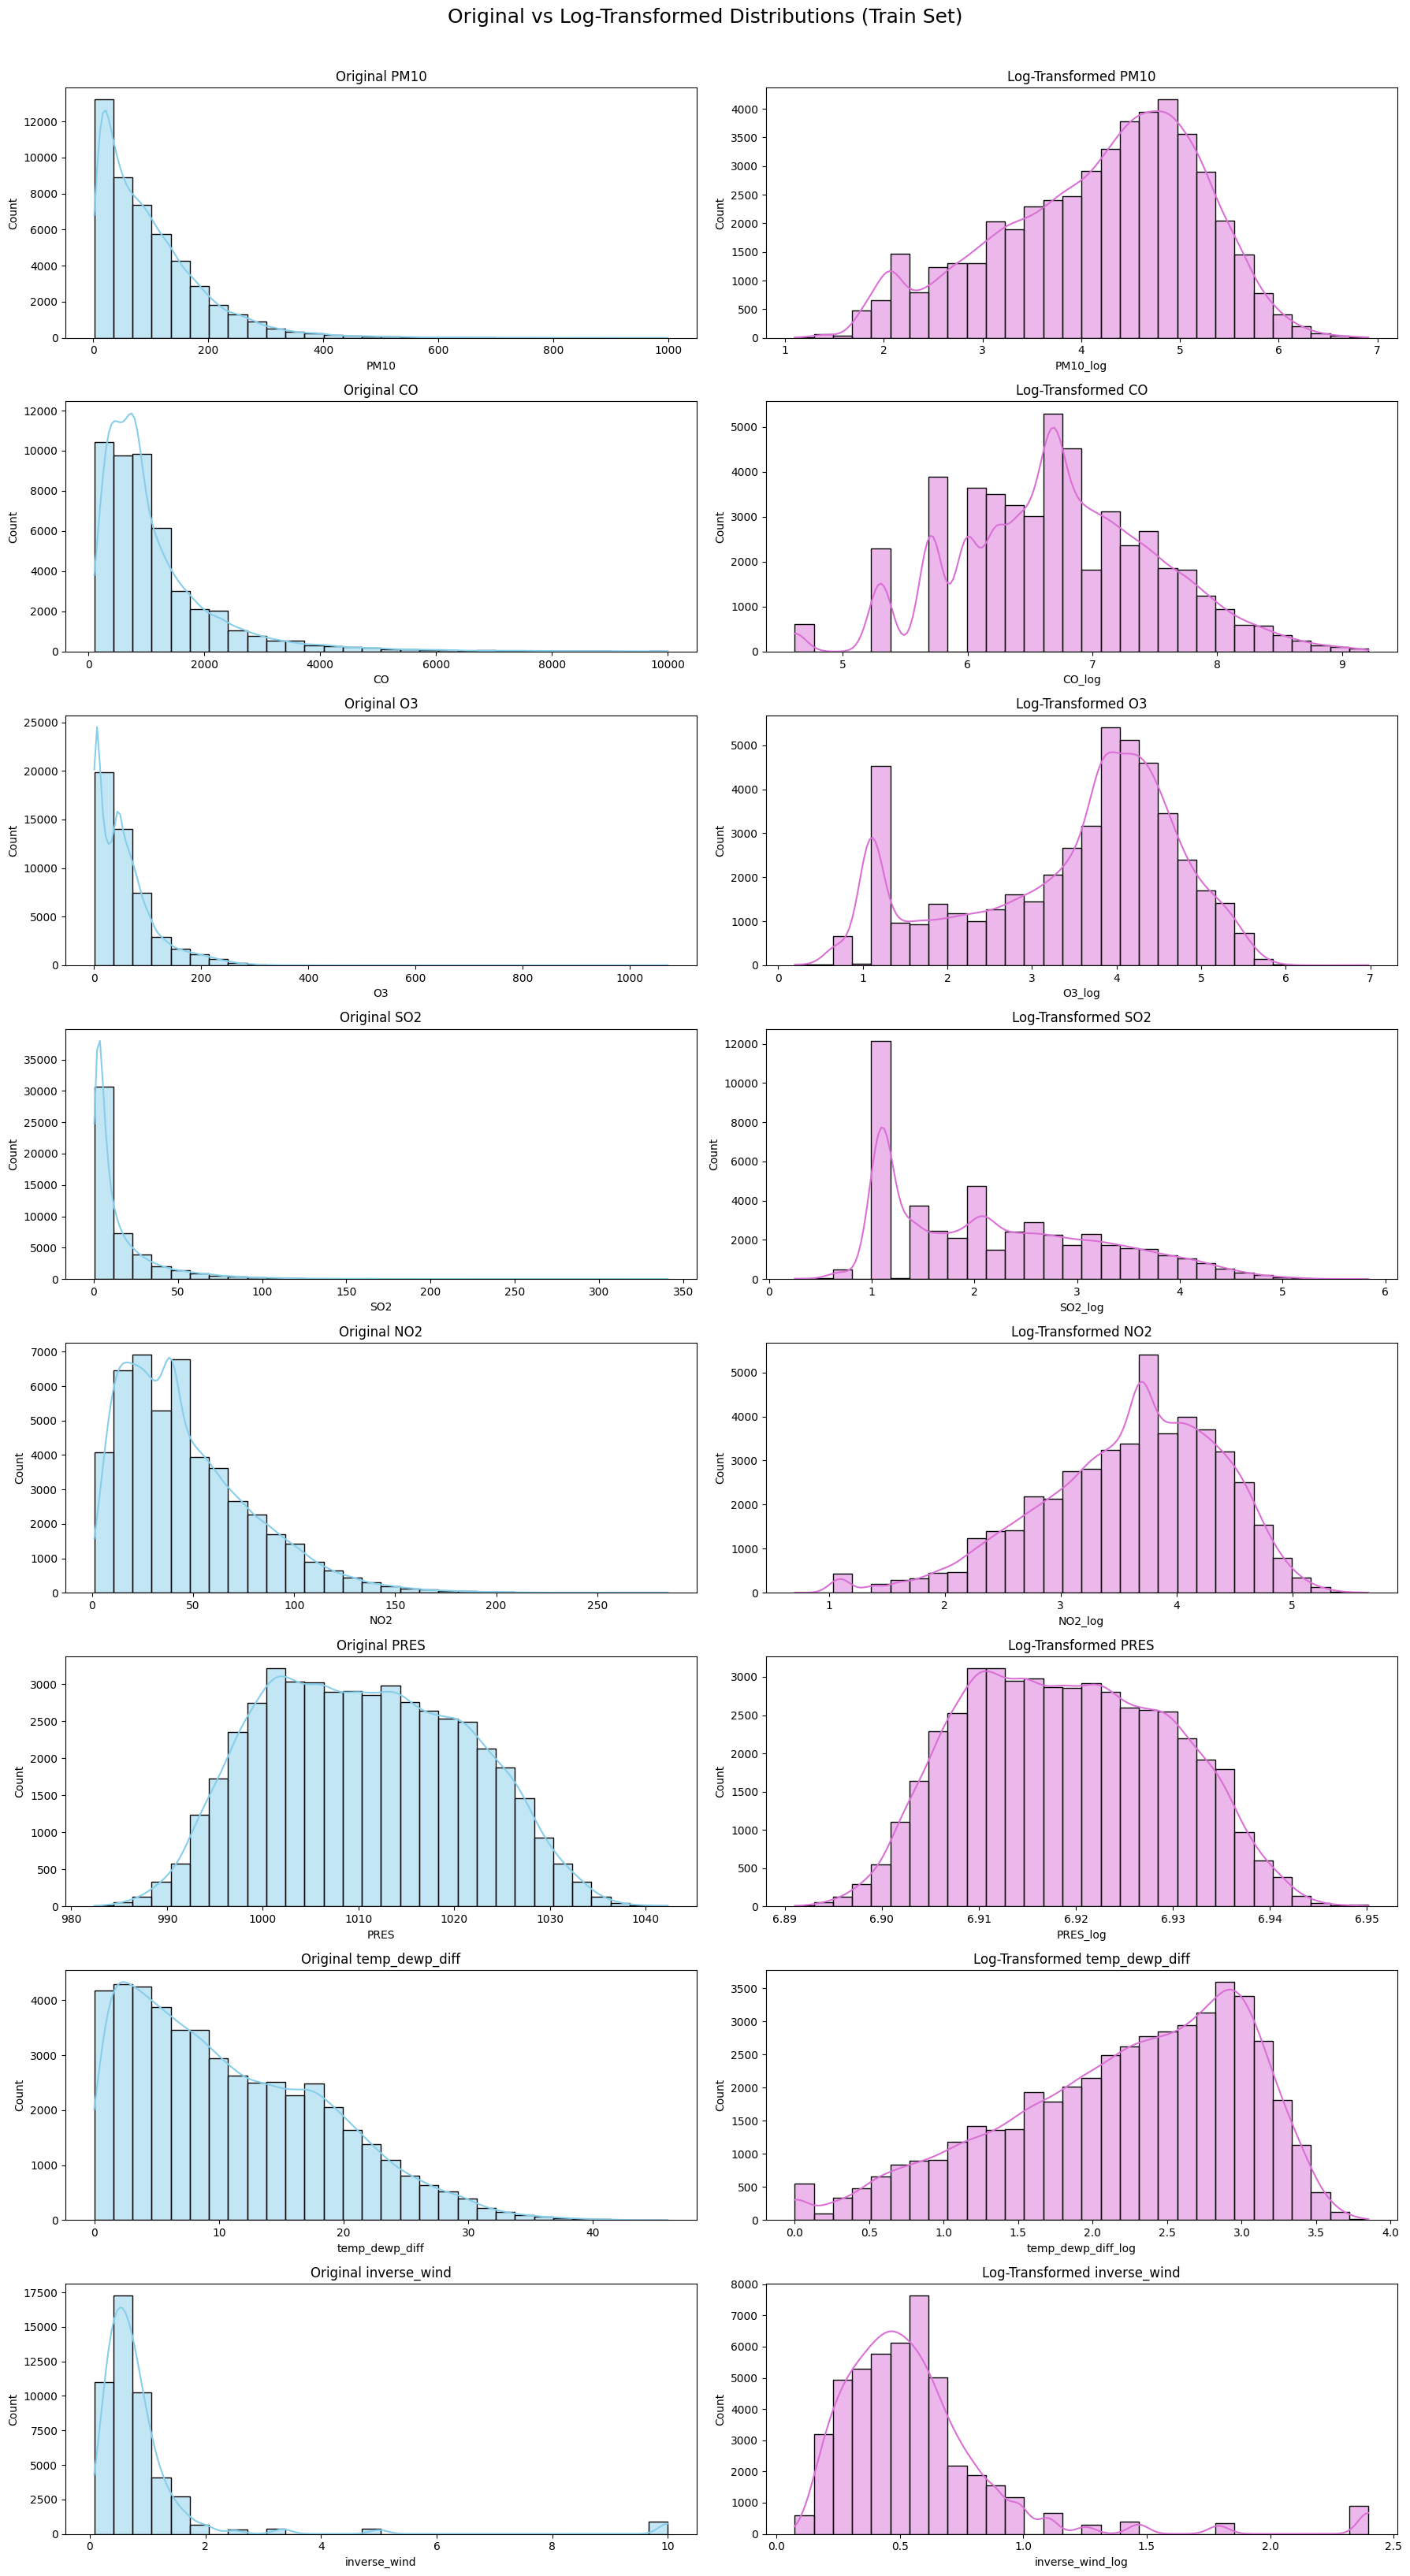

In [ ]:
log_vars = ['PM10', 'CO', 'O3', 'SO2', 'NO2', 'PRES', 'temp_dewp_diff', 'inverse_wind']
num_vars = len(log_vars)

plt.figure(figsize=(18, num_vars * 4))

for i, var in enumerate(log_vars):
    # Original distribution
    plt.subplot(num_vars, 2, 2*i + 1)
    sns.histplot(X_train[var], bins=30, kde=True, color='skyblue')
    plt.title(f'Original {var}', fontsize=12)

    # Log-transformed distribution
    plt.subplot(num_vars, 2, 2*i + 2)
    sns.histplot(X_train[f'{var}_log'], bins=30, kde=True, color='orchid')
    plt.title(f'Log-Transformed {var}', fontsize=12)

plt.tight_layout()
plt.suptitle("Original vs Log-Transformed Distributions (Train Set)", fontsize=18, y=1.02)
plt.show()

In [ ]:
X_train.drop(columns=log_vars, inplace=True)
X_test.drop(columns=log_vars, inplace=True)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48000 entries, 141860 to 170936
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   month               48000 non-null  int64  
 1   wd                  48000 non-null  object 
 2   station             48000 non-null  object 
 3   night_time          48000 non-null  int64  
 4   Rain_Flag           48000 non-null  int64  
 5   CO_NO2_ratio        44355 non-null  float64
 6   PM10_log            48000 non-null  float64
 7   CO_log              48000 non-null  float64
 8   O3_log              48000 non-null  float64
 9   SO2_log             48000 non-null  float64
 10  NO2_log             48000 non-null  float64
 11  PRES_log            48000 non-null  float64
 12  temp_dewp_diff_log  48000 non-null  float64
 13  inverse_wind_log    48000 non-null  float64
dtypes: float64(9), int64(3), object(2)
memory usage: 5.5+ MB


# Feature Encoding

In [ ]:
categorical_features = ['station', 'wd']

ohe_pipeline = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train_encoded_array = ohe_pipeline.fit_transform(X_train)
X_test_encoded_array = ohe_pipeline.transform(X_test)

In [ ]:
ohe_feature_names = ohe_pipeline.named_transformers_['cat'].get_feature_names_out(categorical_features)
remainder_features = [col for col in X_train.columns if col not in categorical_features]
final_feature_names = list(ohe_feature_names) + remainder_features


X_train_encoded = pd.DataFrame(X_train_encoded_array, columns=final_feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded_array, columns=final_feature_names, index=X_test.index)

# Check for Multicollinarity using Heatmap

# 🔁 Multicollinearity Analysis in Beijing Air Pollution Dataset

The **correlation matrix** visualization provides important insights into the relationships between variables in the air pollution dataset after **log transformation**. This analysis is crucial to identify **redundant features** and understand how variables interact with each other.

---

## 📌 Key Observations from the Correlation Matrix

### 1. **Strong Correlations Between Pollutants**

Several pairs of **log-transformed pollutants** exhibit moderate to strong correlations:

- **CO_log and NO2_log**  
  ➤ Strong positive correlation (~**0.69**)  
  ➤ Indicates both are likely emitted from **common sources** (e.g., vehicular traffic)

- **CO_log and PM10_log**  
  ➤ Positive correlation (~**0.66**)  
  ➤ Suggests overlap in **atmospheric behavior or emission origin**

- **SO2_log and NO2_log**  
  ➤ Moderate correlation (~**0.52**)  
  ➤ Reflects a **shared combustion-based origin** (e.g., fossil fuels)

- **O3_log and SO2_log**  
  ➤ Negative correlation (~**-0.21**)  
  ➤ Suggests **inversely related atmospheric conditions**

- **PM10_log and SO2_log**  
  ➤ Positive correlation (~**0.47**)  
  ➤ Likely influenced by **industrial emissions**

---

### 2. **Meteorological Factors and Pollutants**

Correlations with **weather-related features** reveal meaningful environmental insights:

- **temp_dewp_diff_log and O3_log**  
  ➤ Positive correlation (~**0.42**)  
  ➤ Indicates ozone formation is enhanced in **dry conditions**

- **temp_dewp_diff_log and CO_log**  
  ➤ Negative correlation (~**-0.40**)  
  ➤ Suggests CO concentrations rise in **humid/stagnant conditions**

- **inverse_wind_log and temp_dewp_diff_log**  
  ➤ Negative correlation (~**-0.42**)  
  ➤ Faster wind reduces temperature-dew point spread

---

### 3. **Station-Related Correlations**

- **Dummy station variables** show expected **negative correlations** (~**-0.25**) due to being **mutually exclusive**.
- No strong direct correlations between **specific stations** and **pollutants**.
  ➤ Suggests air pollution patterns are **relatively uniform** across stations.

---

## 💡 Implications for Modeling

### ✅ Why Tree-Based Models Are Appropriate:

Tree-based algorithms (e.g., **Random Forest**, **XGBoost**, **CatBoost**) handle multicollinearity effectively because they:

- 🔄 Model **non-linear interactions** between features
- ✅ Perform **implicit feature selection** at each tree split
- 📦 Are **robust to multicollinearity**, unlike linear regression




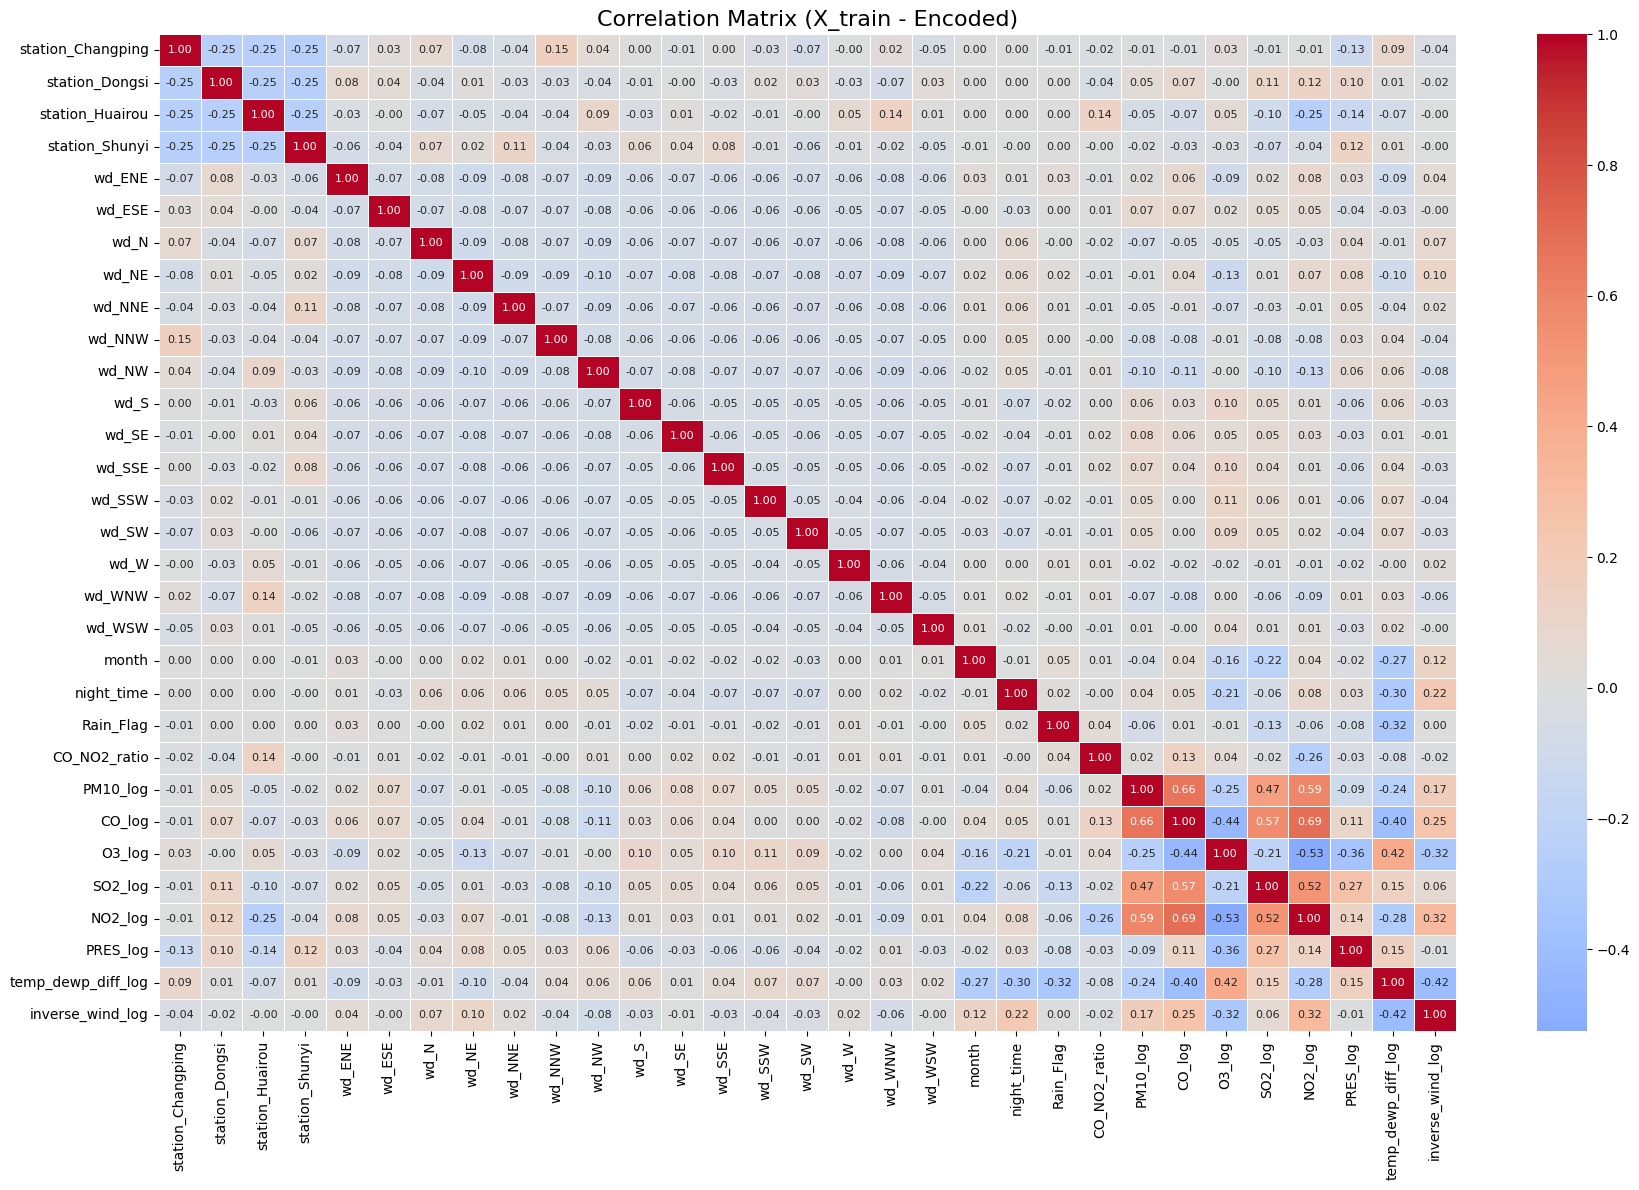

In [ ]:
plt.figure(figsize=(18, 12))
corr_matrix = X_train_encoded.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5,
            annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Correlation Matrix (X_train - Encoded)", fontsize=16)
plt.tight_layout()
plt.show()

### Split between categorical and Numeric features

In [ ]:
station_wd_features = []
for features in X_train_encoded.columns:
    if features.startswith('station_') or features.startswith('wd_'):
        station_wd_features.append(features)

numeric_features = []
for feat in X_train_encoded.columns:
    if feat not in station_wd_features:
        numeric_features.append(feat)

# Dealing with Imbalance

#  Dealing with Class Imbalance Using SMOTE

In many real-world classification problems, including air pollution categorization, the target classes (e.g., "Low", "Moderate", "High") are often *imbalanced* — meaning some classes appear much more frequently than others.

This imbalance can bias machine learning models toward the *majority class*, reducing performance on minority (less frequent) categories.

---

##  What is SMOTE?

*SMOTE (Synthetic Minority Over-sampling Technique)* is an advanced oversampling method that:

- 📌 *Synthesizes new data points* for minority classes
- ✅ Helps the model learn better by balancing class distribution
- 📊 Works by creating *interpolated samples* between existing points in the minority class

In [ ]:
X_train_encoded[numeric_features] = X_train_encoded[numeric_features].fillna(X_train_encoded[numeric_features].median())
X_test_encoded[numeric_features] = X_test_encoded[numeric_features].fillna(X_test_encoded[numeric_features].median())
smote = SMOTE(random_state=42)
X_train_numeric_smote, y_train_smote = smote.fit_resample(X_train_encoded[numeric_features], y_train)

In [ ]:
y_train_smote.value_counts()

,count
PM2.5_category_encoded,
0,18075
2,18075
1,18075


## Repeat the categorical rows to match smote for numerical values

Since SMOTE only altered the numeric features, the original categorical part is now too short

So you repeat the categorical data to match the number of oversampled rows.

In [ ]:
repeat_factor = int(X_train_numeric_smote.shape[0] / X_train_encoded.shape[0])
X_train_station_wd_repeated = pd.DataFrame(
    np.repeat(X_train_encoded[station_wd_features].values, repeat_factor, axis=0),
    columns=station_wd_features
)

## Combine them into dataframe

In [ ]:
X_train_combined = pd.concat([X_train_station_wd_repeated.reset_index(drop=True),
                              pd.DataFrame(X_train_numeric_smote, columns=numeric_features).reset_index(drop=True)],
                             axis=1)

# Feature Scaling

## Only fit the numerical features using feature scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = X_train_combined.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_scaled[numeric_features])

# Prepare and scale test data
X_test_scaled = X_test_encoded[station_wd_features + numeric_features].copy()
X_test_scaled[numeric_features] = scaler.transform(X_test_scaled[numeric_features])

In [ ]:
X_train_scaled = X_train_scaled.dropna()
y_train_smote = y_train_smote[X_train_scaled.index]

# Modelling

# SMOTE baseline

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "LightGBM": LGBMClassifier(verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=0)
}

In [ ]:
def evaluate_baseline_models(models, X_train_scaled, y_train_smote, X_test_scaled, y_test):

    results = []
    trained_models = {}

    for name, model in models.items():
        print(f"\nTraining: {name}")
        model.fit(X_train_scaled, y_train)
        trained_models[name] = model

        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)

        train_acc = accuracy_score(y_train, y_pred_train)
        test_acc = accuracy_score(y_test, y_pred_test)
        precision = precision_score(y_test, y_pred_test, average='weighted')
        recall = recall_score(y_test, y_pred_test, average='weighted')
        f1 = f1_score(y_test, y_pred_test, average='weighted')

        try:
            y_proba = model.predict_proba(X_test_scaled)
            roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        except:
            roc_auc = 'N/A'

        print(f"Test Accuracy: {test_acc:.4f}")
        print("Classification Report:\n", classification_report(y_test, y_pred_test))

        results.append({
            'Model': name,
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Precision': precision,
            'Recall': recall,
            'F1-score': f1,
            'ROC AUC': roc_auc
        })

    results_df = pd.DataFrame(results)
    return results_df, trained_models

In [ ]:
baseline_results_df, baseline_models = evaluate_baseline_models(
    models,
    X_train_scaled,
    y_train_smote,
    X_test_scaled,
    y_test
)


Training: LogisticRegression
Test Accuracy: 0.8170
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      4469
           1       0.87      0.86      0.86      4550
           2       0.65      0.62      0.63      2981

    accuracy                           0.82     12000
   macro avg       0.80      0.79      0.80     12000
weighted avg       0.81      0.82      0.82     12000


Training: KNN
Test Accuracy: 0.8069
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      4469
           1       0.88      0.88      0.88      4550
           2       0.64      0.57      0.61      2981

    accuracy                           0.81     12000
   macro avg       0.78      0.78      0.78     12000
weighted avg       0.80      0.81      0.80     12000


Training: Random Forest
Test Accuracy: 0.8706
Classification Report:
               precision    rec

In [ ]:
print("\nModel Comparison:")
display(baseline_results_df)


Model Comparison:


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC
0,LogisticRegression,0.820167,0.817000,0.814800,0.817000,0.815674,0.933824
1,KNN,0.876854,0.806917,0.801916,0.806917,0.803548,0.923863
2,Random Forest,1.000000,0.870583,0.869190,0.870583,0.869640,0.967795
3,AdaBoost,0.820875,0.817833,0.814750,0.817833,0.815777,0.915253
4,LightGBM,0.897333,0.865250,0.865691,0.865250,0.865312,0.966587
5,CatBoost,0.912917,0.872500,0.872548,0.872500,0.872396,0.968600


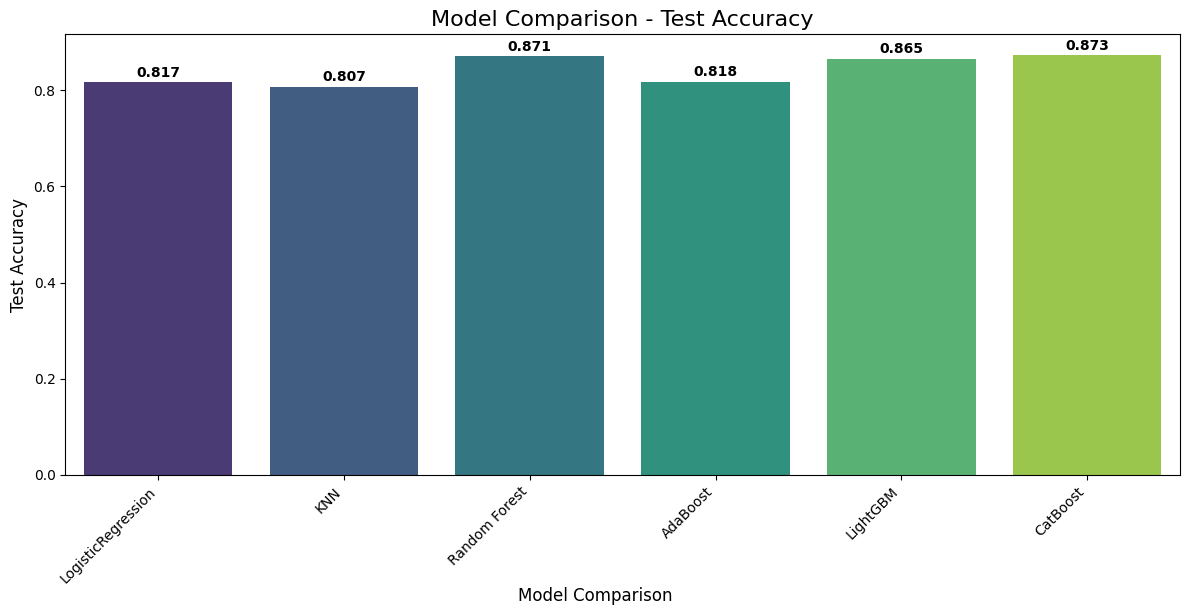

In [ ]:
plot_data = baseline_results_df.reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Test Accuracy', data=plot_data, palette='viridis', dodge=False)

plt.title('Model Comparison - Test Accuracy', fontsize=16)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

# Annotate bars with values
for i, v in enumerate(plot_data['Test Accuracy']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.figtext(0.5, -0.01, 'Model Comparison', ha='center', fontsize=12)
plt.show()

In [ ]:
tuned_models = {
    "Logistic Regression": {
        'model': LogisticRegression(max_iter=1000,),
        'params': {
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
            'fit_intercept': [True]
        }
    },

    "LightGBM": {
        'model': LGBMClassifier(verbose=-1),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.03, 0.05],
            'num_leaves': [15, 31],
            'max_depth': [3, 6],
            'reg_alpha': [0.0, 0.1],
            'reg_lambda': [0.0, 0.1],
            'boosting_type': ['gbdt']
        }
    },

    "KNN": {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        }
    },

    "Random Forest": {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [6, 10],
            'min_samples_split': [5],
            'min_samples_leaf': [4],
            'max_features': ['sqrt'],
            'bootstrap': [True]
        }
    },

    "AdaBoost": {
        'model': AdaBoostClassifier(),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.05],
            'algorithm': ['SAMME']
        }
    },

    "CatBoost": {
        'model': CatBoostClassifier(verbose=0),
        'params': {
            'iterations': [100, 200],
            'learning_rate': [0.03, 0.05],
            'depth': [3, 4],
            'l2_leaf_reg': [5, 10],
            'boosting_type': ['Ordered']
        }
    },
}


In [ ]:
def fit_and_evaluate_tuned_models(tuned_models, X_train_scaled, y_train_smote, X_test_scaled, y_test, n_iter=20):
    results = []
    trained_models = {}

    for name, model_info in tuned_models.items():
        print(f"\n Tuning and Training: {name}")

        model = model_info['model']
        param_distributions = model_info['params']

        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_distributions,
            n_iter=n_iter,
            cv=5,
            scoring='f1_macro',
            n_jobs=-1,
            random_state=42
        )

        random_search.fit(X_train_scaled, y_train)
        best_model = random_search.best_estimator_

        trained_models[name] = best_model

        y_train_pred = best_model.predict(X_train_scaled)
        y_test_pred = best_model.predict(X_test_scaled)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        precision = precision_score(y_test, y_test_pred, average='weighted')
        recall = recall_score(y_test, y_test_pred, average='weighted')
        f1 = f1_score(y_test, y_test_pred, average='weighted')

        try:
            y_test_proba = best_model.predict_proba(X_test_scaled)
            if y_test_proba.shape[1] == 2:
                roc_auc = roc_auc_score(y_test, y_test_proba[:, 1])
            else:
                roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr')
        except:
            roc_auc = "N/A"

        print(f"Best Parameters: {random_search.best_params_}")
        print(f"{name} - Test Accuracy: {test_acc:.4f}, F1: {f1:.4f}, ROC AUC: {roc_auc}")
        print("Classification Report:\n", classification_report(y_test, y_test_pred))

        results.append({
            "Model": name,
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "ROC AUC": roc_auc
        })

    results_df = pd.DataFrame(results).set_index("Model").round(4)
    return results_df, trained_models


In [ ]:
tuned_results_df, trained_models = fit_and_evaluate_tuned_models(
    tuned_models,
    X_train_scaled,
    y_train_smote,
    X_test_scaled,
    y_test
)


 Tuning and Training: Logistic Regression
Best Parameters: {'solver': 'saga', 'penalty': 'l1', 'fit_intercept': True}
Logistic Regression - Test Accuracy: 0.8175, F1: 0.8162, ROC AUC: 0.9338342499576672
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      4469
           1       0.87      0.86      0.86      4550
           2       0.65      0.62      0.63      2981

    accuracy                           0.82     12000
   macro avg       0.80      0.80      0.80     12000
weighted avg       0.82      0.82      0.82     12000


 Tuning and Training: LightGBM
Best Parameters: {'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'boosting_type': 'gbdt'}
LightGBM - Test Accuracy: 0.8664, F1: 0.8663, ROC AUC: 0.9661151412815298
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.91     

# ✅ Model Selection Justification: Why We Chose LightGBM

After evaluating multiple machine learning models on the Beijing air pollution dataset, we selected **LightGBM** as our final model. The decision is based on a comprehensive comparison of performance metrics, model efficiency, and generalization ability.

---

## 📊 Performance Comparison

| Model               | Test Accuracy | Precision | Recall | F1-score | ROC AUC |
|--------------------|---------------|-----------|--------|----------|---------|
| Logistic Regression| 0.8175        | 0.8153    | 0.8175 | 0.8162   | 0.9338  |
| **LightGBM**       | **0.8664**    | **0.8665**| **0.8664** | **0.8663** | **0.9661** |
| KNN                | 0.8370        | 0.8352    | 0.8370 | 0.8358   | 0.9441  |
| Random Forest      | 0.8532        | 0.8504    | 0.8532 | 0.8512   | 0.9579  |
| AdaBoost           | 0.7887        | 0.7797    | 0.7887 | 0.7808   | 0.9153  |
| CatBoost           | 0.8501        | 0.8483    | 0.8501 | 0.8489   | 0.9572  |

---

## ✅ Why LightGBM?

### 🔹 1. **Highest Overall Test Performance**
- LightGBM achieved the **highest scores** in nearly all major evaluation metrics:
  - **Test Accuracy**: 86.64%
  - **Precision, Recall, F1-score**: ~86.6%
  - **ROC AUC**: **0.9661** (indicates excellent class separability)

### 🔹 2. **Better Generalization**
- Unlike **KNN**, which showed signs of overfitting (Train Accuracy = 100%), LightGBM maintained a healthy balance between **Train Accuracy (89.4%)** and **Test Accuracy (86.6%)**, suggesting **strong generalization** to unseen data.

### 🔹 3. **Efficient with Large Data**
- LightGBM is optimized for **speed and memory usage**, especially with large tabular datasets like ours, which includes both numerical and categorical features.

### 🔹 4. **Handles Categorical Features Automatically**
- LightGBM can natively handle **categorical variables** and **missing values**, which reduces the need for extensive preprocessing.

### 🔹 5. **Robust to Multicollinearity**
- Unlike linear models (e.g., Logistic Regression), LightGBM is **not sensitive to feature correlation**, making it suitable for our dataset where pollutants may be correlated (as shown in the correlation matrix).




In [ ]:
print("\nTuned Model Comparison:")
display(tuned_results_df)


Tuned Model Comparison:


,Train Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC
Model,,,,,,
Logistic Regression,0.8203,0.8175,0.8153,0.8175,0.8162,0.9338
LightGBM,0.8940,0.8664,0.8665,0.8664,0.8663,0.9661
KNN,1.0000,0.8370,0.8352,0.8370,0.8358,0.9441
Random Forest,0.8754,0.8532,0.8504,0.8532,0.8512,0.9579
AdaBoost,0.7866,0.7887,0.7797,0.7887,0.7808,0.9153
CatBoost,0.8533,0.8501,0.8483,0.8501,0.8489,0.9572


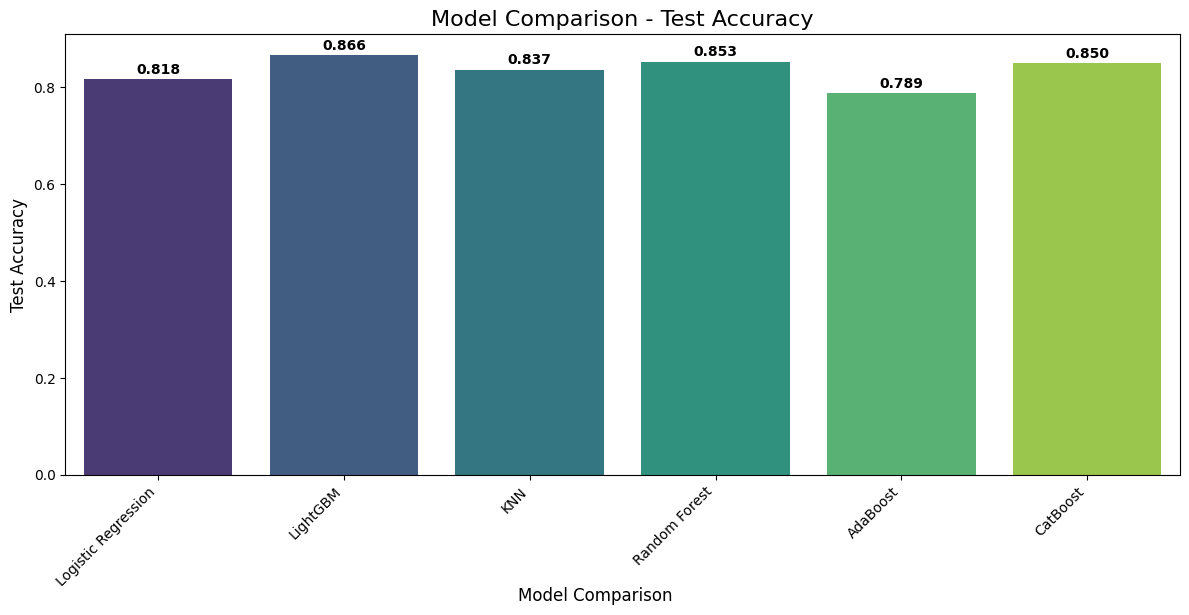

In [ ]:
plot_data_tuned = tuned_results_df.reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Test Accuracy', data=plot_data_tuned, palette='viridis', dodge=False)

plt.title('Model Comparison - Test Accuracy', fontsize=16)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(plot_data_tuned['Test Accuracy']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.figtext(0.5, -0.01, 'Model Comparison', ha='center', fontsize=12)
plt.show()

In [ ]:
LightGBM = trained_models.get("LightGBM")
best_model = trained_models["LightGBM"]

Feature Importance Analysis

Understanding which features most strongly influence predictions helps with model interpretability. The plot below shows the top features ranked by importance in the LightGBM model.

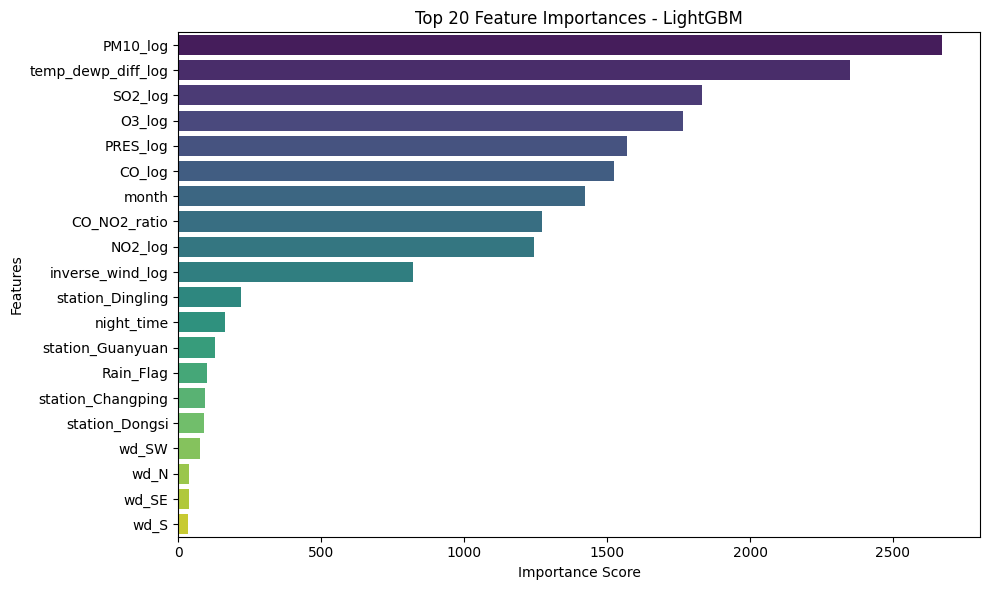

In [ ]:
model_name = "LightGBM"
model = trained_models[model_name]

feature_names = final_feature_names

if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=importances[indices][:20],
        y=np.array(feature_names)[indices][:20],
        palette='viridis'
    )
    plt.title(f"Top 20 Feature Importances - {model_name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

elif hasattr(model, 'coef_'):
    coefs = model.coef_
    if coefs.ndim > 1:
        coefs = np.mean(coefs, axis=0)
    indices = np.argsort(np.abs(coefs))[::-1]

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=coefs[indices][:20],
        y=np.array(feature_names)[indices][:20],
        palette='coolwarm'
    )
    plt.title(f"Top 20 Coefficients - {model_name}")
    plt.xlabel("Coefficient Value")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

else:
    print(f"⚠️ {model_name} does not support feature importance or coefficients.")

In [ ]:
def plot_confusion_matrix_weather(model, X_test_scaled, y_test, model_name="LightGBM"):
    """
    Generate and display the confusion matrix for a trained model.
    """
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    unique_classes = np.unique(np.concatenate((y_test, y_pred)))
    class_labels = [f"{cls} (Class)" for cls in unique_classes]

    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False)

    ax.set_title(f'{model_name} - Confusion Matrix (Test Data)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('Actual Label', fontsize=12)

    ax.set_xticklabels(class_labels, fontsize=10)
    ax.set_yticklabels(class_labels, fontsize=10)

    plt.subplots_adjust(bottom=0.25)
    plt.figtext(0.5, -0.01, "Confusion Matrix", ha='center', fontsize=12)

    plt.show()


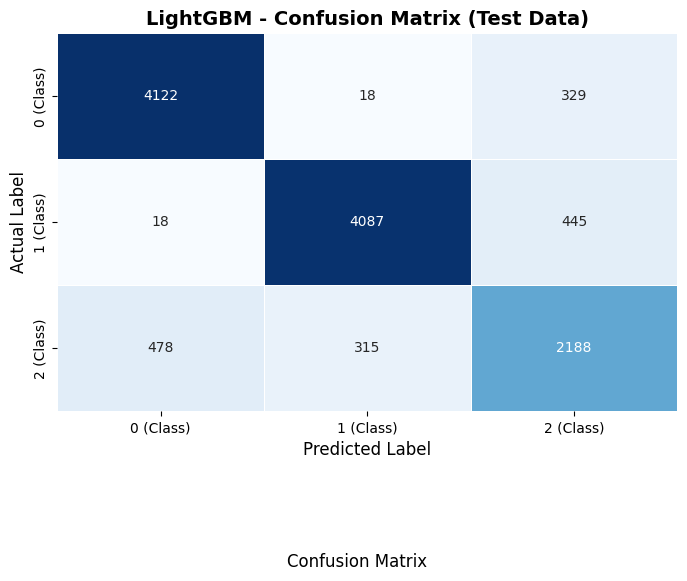

In [ ]:
plot_confusion_matrix_weather(trained_models["LightGBM"], X_test_scaled, y_test, "LightGBM")

In [ ]:
X_test_scaled.shape

(12000, 30)

In [ ]:
with open('LightGBM.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [ ]:
with open('StandardScalar.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# 📊 SHAP Feature Importance Analysis

The SHAP (SHapley Additive exPlanations) summary plot shown above provides a **global view** of how each feature contributes to the prediction of PM2.5 pollution categories — **High**, **Low**, and **Moderate**.

This plot is **stacked by class**, so we can clearly observe which features impact each pollution level and by how much.

---

## 🔍 Key Insights from the SHAP Plot

### 1. **Top Influential Features**
- **PM10_log** is the most dominant feature across all classes, especially for predicting **High** pollution.  
  ➤ This makes sense, as PM10 and PM2.5 are often strongly correlated and are both particulate pollutants.

- **CO_log** is the second-most important feature.  
  ➤ Its impact is highest for the **Low** and **Moderate** classes, indicating it helps distinguish between cleaner and borderline air quality.

- **temp_dewp_diff_log** (temperature minus dew point) plays a major role in **Moderate** class predictions.  
  ➤ This reflects how **atmospheric moisture** and humidity influence pollution dispersion.

- **SO2_log** contributes moderately across all classes, especially for **High** and **Low** levels.  
  ➤ Indicates industrial/fossil fuel impacts on pollution.

- **month** (seasonality) affects all classes, reflecting seasonal patterns in Beijing’s air quality.

---

### 2. **Meteorological & Location-Based Factors**
- **O3_log**, **NO2_log**, and **PRES_log** have a **moderate contribution**, indicating weather and chemical conditions impact predictions.

- Location indicators like **station_Dongsi**, **station_Shunyi**, and **station_Changping** have smaller yet noticeable influence — especially for urban station Dongsi, which contributes slightly more for **High** levels.

- **Wind direction features** (e.g., `wd_S`, `wd_SW`) and **night_time** have minimal SHAP values, indicating they play a minor role in the final predictions.

---

## ✅ Why This Matters

- SHAP explains **why LightGBM predicted a certain class**, giving transparency and interpretability to the model.
- **PM10, CO, and meteorological factors** are critical for identifying pollution severity, which validates domain expectations.
- Feature importance also informs **policy priorities** — such as reducing particulate and vehicle emissions to improve air quality.

---

The SHAP values confirm:
- The model is learning from **physically relevant features**
- **Particulate matter, CO, and weather** dominate prediction logic
- Location plays a smaller, contextual role

This kind of interpretability is crucial for **trust in AI-driven environmental tools**, especially when communicating findings to stakeholders or policy-makers.


In [ ]:
with open("LightGBM.pkl", "rb") as f:
    best_model = pickle.load(f)

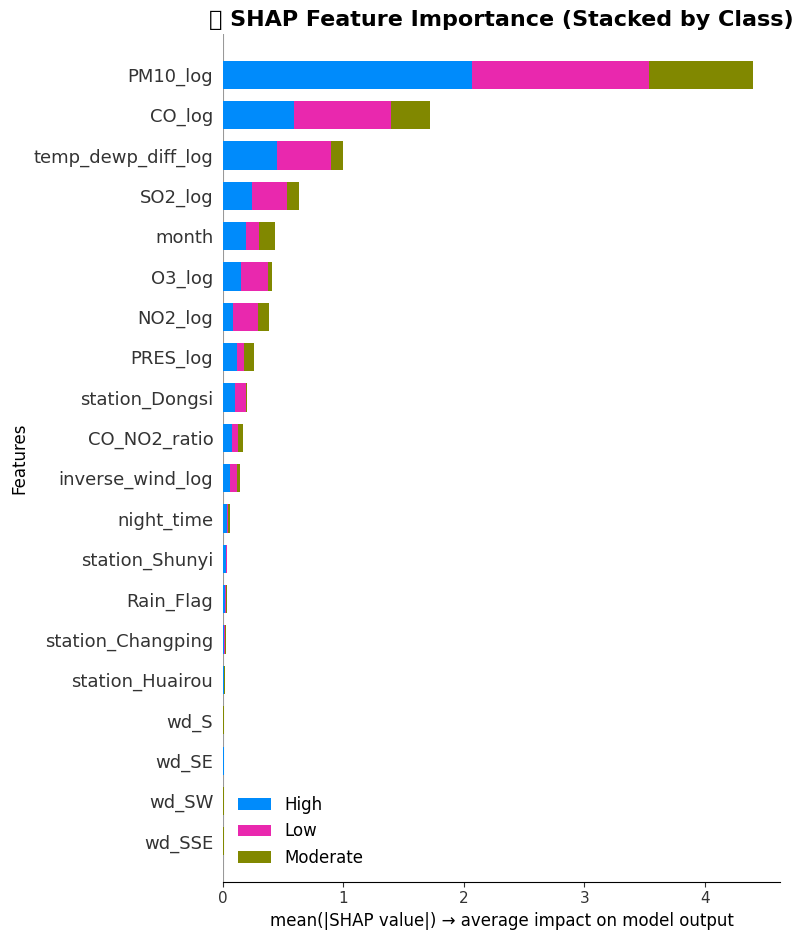

In [ ]:
X_test_df = pd.DataFrame(X_test_scaled, columns=final_feature_names).astype(float)

explainer = shap.Explainer(best_model)
shap_values = explainer(X_test_df)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=final_feature_names,
    plot_type="bar",
    class_names=["High", "Low", "Moderate"],
    show=False
)

plt.title("🔍 SHAP Feature Importance (Stacked by Class)", fontsize=16, weight='bold')
plt.xlabel("mean(|SHAP value|) → average impact on model output", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()

plt.savefig("shap_summary_stacked_bar.png", dpi=300)
plt.show()